# Proyecto Machine Learning: ENTRENAMIENTO DE MODELOS

### Análisis predictivo de la gestión de la ayuda humanitaria y el impacto de desastres a nivel global

In [1]:
# Librerías

import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
base_dir = os.path.dirname(os.path.abspath("__file__"))
csv_path = os.path.join(base_dir, "..", "data", "desastres_y_respuestas_limpio_FE.csv")
df = pd.read_csv(csv_path)

## SELECCIÓN DE VARIABLES

* Objetivo 1 (target: response_score):  

*Asumo que el score de la respuesta tiene en cuenta los días que se tardó en recuperarse (recovery_days)

Prescindo de: 
- response_hours y response_hours_log - leakage directo (correlación muy alta)
- casualties, economic_loss, aid_amount, recovery_days, response_hours - versiones originales, sustituidas por las log

In [3]:
# Columnas a excluir del objetivo 1 (con severity_index)
excluir_obj1 = [
    'response_score',       # target
    'response_hours',       # leakage
    'response_hours_log',   # leakage
    'casualties', 'economic_loss', 'aid_amount', 'recovery_days' # versiones originales — usamos las log
]

X1 = df.drop(columns=excluir_obj1)
y1 = df['response_score']

In [4]:
# Columnas a excluir del objetivo 1 (sin severity_index)
excluir_obj1 = [
    'response_score',       # target
    'response_hours',       # leakage
    'response_hours_log',   # leakage
    'severity_index',       # leakage
    'casualties', 'economic_loss', 'aid_amount', 'recovery_days' # versiones originales — usamos las log
]

X1_2 = df.drop(columns=excluir_obj1)
y1_2 = df['response_score']

* Objetivo 2 (target: recovery_days_log, luego lo transformo de vuelta con np.expm1()):  

Prescindo de: 
- response_score - leakage temporal según mi criterio, porque para mí el score tiene en cuenta los días de respuesta
- versiones originales de las log: casualties, economic_loss, aid_amount, response_hours

In [5]:
excluir_obj2 = [
    'recovery_days',        # target
    'recovery_days_log',    # target en log
    'response_score',       # leakage temporal
    'casualties', 'economic_loss', 'aid_amount', 'response_hours' # versiones originales
]

X2 = df.drop(columns=excluir_obj2)
y2 = df['recovery_days_log']

* Objetivo 3 (clustering):

In [6]:
cols_clust = ['casualties_log', 'economic_loss_log', 
              'response_hours_log', 'recovery_days_log']

X3 = df[cols_clust]

## TRAIN-TEST SPLIT Y ESTANDARIZACIÓN

Variables como casualties_log y severity_index están en escalas muy distintas - una va de 0 a 12, la otra de 0 a 10, pero las columnas OHE van de 0 a 1. Los modelos que trabajan con distancias (regresión lineal, SVM, KMeans) interpretarían que las variables con números más grandes son más importantes, cuando eso no es verdad. El StandardScaler convierte cada variable para que tenga media 0 y desviación típica 1.  

Importante: el scaler se ajusta (fit) solo con los datos de entrenamiento y luego se aplica (transform) tanto a train como a test. Si lo ajustas con todos los datos estás filtrando información del test al train — otro tipo de leakage.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42)

X1_2_train, X1_2_test, y1_2_train, y1_2_test = train_test_split(
    X1_2, y1_2, test_size=0.2, random_state=42)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

# X3 no necesita split — clustering usa todos los datos

print(X1_train.shape, X1_test.shape)
print(X1_2_train.shape, X1_2_test.shape)
print(X2_train.shape, X2_test.shape)

(39976, 42) (9994, 42)
(39976, 41) (9994, 41)
(39976, 42) (9994, 42)


In [11]:
scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X1_train)  
X1_test_sc  = scaler1.transform(X1_test)     

scaler1_2 = StandardScaler()
X1_2_train_sc = scaler1_2.fit_transform(X1_2_train)  
X1_2_test_sc  = scaler1_2.transform(X1_2_test)   

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

scaler3 = StandardScaler()
X3_sc = scaler3.fit_transform(X3)

## MODELADO

* Métricas a usar:

MAE (Mean Absolute Error - Error Absoluto Medio): Calcula la media de las diferencias absolutas entre los valores reales y los predichos. Es fácil de interpretar y no penaliza fuertemente los valores atípicos (outliers).  

RMSE (Root Mean Squared Error - Raíz del Error Cuadrático Medio): Es la raíz cuadrada del MSE. Ofrece una medida en las mismas unidades que la variable objetivo.  

\(R^{2}\) Score (Coeficiente de Determinación): Indica qué tan bien se ajusta el modelo a los datos (1 es ajuste perfecto, 0 o negativo es mal ajuste).

* Objetivo 1 (response_score) - incluyendo "severity-index"

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(X1_train_sc, y1_train)

y1_pred_lr = lr.predict(X1_test_sc)
y1_pred_lr_train = lr.predict(X1_train_sc)

print("── Linear Regression ──")
print(f"R²:     {r2_score(y1_test, y1_pred_lr):.4f}")
print(f"R²_t:   {r2_score(y1_train, y1_pred_lr_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_test, y1_pred_lr):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_train, y1_pred_lr_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_test, y1_pred_lr):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_train, y1_pred_lr_train):.4f}")

── Linear Regression ──
R²:     0.7493
R²_t:   0.7468
RMSE:   14.0286
RMSE_t: 13.9852
MAE:    10.5112
MAE_t:  10.5028


In [23]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# alphas: rango logarítmico para explorar penalización débil y fuerte
alphas = np.logspace(-3, 3, 50) # coge 50 valores entre 10 a la -3 y 10 a la 3

ridge = RidgeCV(alphas=alphas, cv=5) # cross validation de 5
ridge.fit(X1_train_sc, y1_train)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso.fit(X1_train_sc, y1_train)

# l1_ratio: qué proporción de la penalización es Lasso vs Ridge
# [0.1, 0.5, 0.9, 0.95, 1.0] cubre desde casi-Ridge hasta Lasso puro
enet = ElasticNetCV(alphas=alphas,
                    l1_ratio=[0.1, 0.5, 0.9, 0.95, 1.0],
                    cv=5, max_iter=10000, random_state=42)
enet.fit(X1_train_sc, y1_train)

for nombre, modelo in [("Ridge", ridge), ("Lasso", lasso), ("ElasticNet", enet)]:
    pred_test  = modelo.predict(X1_test_sc)
    pred_train = modelo.predict(X1_train_sc)
    print(f"── {nombre} ──")
    print(f"  alpha óptimo: {modelo.alpha_:.4f}")
    print(f"  R²:     {r2_score(y1_test, pred_test):.4f}")
    print(f"  R²_t:   {r2_score(y1_train, pred_train):.4f}")
    print(f"  RMSE:   {root_mean_squared_error(y1_test, pred_test):.4f}")
    print(f"  RMSE_t: {root_mean_squared_error(y1_train, pred_train):.4f}")
    print(f"  MAE:    {mean_absolute_error(y1_test, pred_test):.4f}")
    print(f"  MAE_t:  {mean_absolute_error(y1_train, pred_train):.4f}")
    print()

── Ridge ──
  alpha óptimo: 8.2864
  R²:     0.7493
  R²_t:   0.7468
  RMSE:   14.0285
  RMSE_t: 13.9852
  MAE:    10.5109
  MAE_t:  10.5027

── Lasso ──
  alpha óptimo: 0.0010
  R²:     0.7493
  R²_t:   0.7468
  RMSE:   14.0286
  RMSE_t: 13.9852
  MAE:    10.5115
  MAE_t:  10.5031

── ElasticNet ──
  alpha óptimo: 0.0010
  R²:     0.7493
  R²_t:   0.7468
  RMSE:   14.0286
  RMSE_t: 13.9852
  MAE:    10.5114
  MAE_t:  10.5031



In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_rf = {
    'n_estimators': [100, 200, 300],       # número de árboles
    'max_depth': [5, 10, 20, 30],       # profundidad máxima por árbol
    'min_samples_split': [2, 5, 10],       # mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4],         # mínimo de muestras en hoja
    'max_features': ['sqrt', 'log2', 0.5]  # features consideradas por split
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=20,          # 20 combinaciones aleatorias (vs todas en GridSearch)
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X1_train_sc, y1_train)

y1_pred_rf       = rf_search.predict(X1_test_sc)
y1_pred_rf_train = rf_search.predict(X1_train_sc)

print("Mejores hiperparámetros RF:", rf_search.best_params_)
print(f"R²:     {r2_score(y1_test, y1_pred_rf):.4f}")
print(f"R²_t:   {r2_score(y1_train, y1_pred_rf_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_test, y1_pred_rf):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_train, y1_pred_rf_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_test, y1_pred_rf):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_train, y1_pred_rf_train):.4f}")

Mejores hiperparámetros RF: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}
R²:     0.9904
R²_t:   0.9966
RMSE:   2.7487
RMSE_t: 1.6226
MAE:    1.0851
MAE_t:  0.5625


In [25]:
importances = pd.Series(
    rf_search.best_estimator_.feature_importances_,
    index=X1.columns
).sort_values(ascending=False)

print(importances.head(10))

casualties_log           0.582605
severity_index           0.254761
country_Bangladesh       0.036566
year                     0.027448
country_Nigeria          0.023326
country_Brazil           0.022401
economic_loss_log        0.017630
recovery_days_log        0.010487
aid_amount_log           0.007404
country_United States    0.005482
dtype: float64


Ahí está el problema. casualties_log y severity_index juntas suman el 84% de la importancia, lo que casi con certeza significa que response_score se calculó a partir de ellas (o que severity_index ya es una combinación de casualties y otras variables).  
Comprueba rápido cómo se definió severity_index en tu notebook de feature engineering. Lo más probable es que sea algo como una media ponderada de casualties_log, economic_loss_log y alguna más — en cuyo caso es leakage doble porque tienes tanto severity_index como sus componentes en X1.

In [26]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_gbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # paso de cada árbol
    'max_depth': [3, 4, 5],                   # árboles poco profundos = mejor en boosting
    'min_samples_leaf': [1, 5, 10],
    'subsample': [0.7, 0.8, 1.0]              # fracción de filas por árbol (stochastic GB)
}

gbm = GradientBoostingRegressor(random_state=42)

gbm_search = RandomizedSearchCV(
    gbm,
    param_distributions=param_dist_gbm,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gbm_search.fit(X1_train_sc, y1_train)

y1_pred_gbm       = gbm_search.predict(X1_test_sc)
y1_pred_gbm_train = gbm_search.predict(X1_train_sc)

print("Mejores hiperparámetros GBM:", gbm_search.best_params_)
print(f"R²:     {r2_score(y1_test, y1_pred_gbm):.4f}")
print(f"R²_t:   {r2_score(y1_train, y1_pred_gbm_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_test, y1_pred_gbm):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_train, y1_pred_gbm_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_test, y1_pred_gbm):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_train, y1_pred_gbm_train):.4f}")

Mejores hiperparámetros GBM: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.1}
R²:     0.9921
R²_t:   0.9931
RMSE:   2.4958
RMSE_t: 2.3099
MAE:    1.1360
MAE_t:  1.1039


In [27]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],  # fracción de features por árbol
    'reg_alpha': [0, 0.1, 1],             # regularización L1
    'reg_lambda': [1, 5, 10]              # regularización L2
}

xgb = XGBRegressor(random_state=42, n_jobs=-1,
                   tree_method='hist',   # más rápido con muchas filas
                   eval_metric='rmse')

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X1_train_sc, y1_train)

y1_pred_xgb       = xgb_search.predict(X1_test_sc)
y1_pred_xgb_train = xgb_search.predict(X1_train_sc)

print("Mejores hiperparámetros XGB:", xgb_search.best_params_)
print(f"R²:     {r2_score(y1_test, y1_pred_xgb):.4f}")
print(f"R²_t:   {r2_score(y1_train, y1_pred_xgb_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_test, y1_pred_xgb):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_train, y1_pred_xgb_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_test, y1_pred_xgb):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_train, y1_pred_xgb_train):.4f}")

Mejores hiperparámetros XGB: {'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
R²:     0.9924
R²_t:   0.9942
RMSE:   2.4454
RMSE_t: 2.1123
MAE:    0.9767
MAE_t:  0.9120


In [ ]:
resultados_obj1 = pd.DataFrame({
    'Modelo': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet',
               'RandomForest', 'GBM', 'XGBoost'],
    'R²': [
        r2_score(y1_test, y1_pred_lr),
        r2_score(y1_test, ridge.predict(X1_test_sc)),
        r2_score(y1_test, lasso.predict(X1_test_sc)),
        r2_score(y1_test, enet.predict(X1_test_sc)),
        r2_score(y1_test, y1_pred_rf),
        r2_score(y1_test, y1_pred_gbm),
        r2_score(y1_test, y1_pred_xgb)
    ],
    'RMSE': [
        root_mean_squared_error(y1_test, y1_pred_lr),
        root_mean_squared_error(y1_test, ridge.predict(X1_test_sc)),
        root_mean_squared_error(y1_test, lasso.predict(X1_test_sc)),
        root_mean_squared_error(y1_test, enet.predict(X1_test_sc)),
        root_mean_squared_error(y1_test, y1_pred_rf),
        root_mean_squared_error(y1_test, y1_pred_gbm),
        root_mean_squared_error(y1_test, y1_pred_xgb)
    ],
    'MAE': [
        mean_absolute_error(y1_test, y1_pred_lr),
        mean_absolute_error(y1_test, ridge.predict(X1_test_sc)),
        mean_absolute_error(y1_test, lasso.predict(X1_test_sc)),
        mean_absolute_error(y1_test, enet.predict(X1_test_sc)),
        mean_absolute_error(y1_test, y1_pred_rf),
        mean_absolute_error(y1_test, y1_pred_gbm),
        mean_absolute_error(y1_test, y1_pred_xgb)
    ]
}).sort_values('R²', ascending=False)

print(resultados_obj1.to_string(index=False))

          Modelo       R²      RMSE       MAE
         XGBoost 0.992382  2.445409  0.976698
             GBM 0.992065  2.495759  1.135990
    RandomForest 0.990375  2.748684  1.085094
           Ridge 0.749291 14.028523 10.510926
      ElasticNet 0.749288 14.028602 10.511394
LinearRegression 0.749287 14.028622 10.511150
           Lasso 0.749287 14.028634 10.511507


* Objetivo 1 (response_score) - excluyendo "severity-index"

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(X1_2_train_sc, y1_2_train)

y1_pred_lr       = lr.predict(X1_2_test_sc)
y1_pred_lr_train = lr.predict(X1_2_train_sc)

print("── Linear Regression ──")
print(f"R²:     {r2_score(y1_2_test, y1_pred_lr):.4f}")
print(f"R²_t:   {r2_score(y1_2_train, y1_pred_lr_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_2_test, y1_pred_lr):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_2_train, y1_pred_lr_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_2_test, y1_pred_lr):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_2_train, y1_pred_lr_train):.4f}")

── Linear Regression ──
R²:     0.6681
R²_t:   0.6600
RMSE:   16.1402
RMSE_t: 16.2075
MAE:    12.1496
MAE_t:  12.2248


In [30]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# alphas: rango logarítmico para explorar penalización débil y fuerte
alphas = np.logspace(-3, 3, 50) # coge 50 valores entre 10 a la -3 y 10 a la 3

ridge = RidgeCV(alphas=alphas, cv=5) # cross validation de 5
ridge.fit(X1_2_train_sc, y1_2_train)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso.fit(X1_2_train_sc, y1_2_train)

# l1_ratio: qué proporción de la penalización es Lasso vs Ridge
# [0.1, 0.5, 0.9, 0.95, 1.0] cubre desde casi-Ridge hasta Lasso puro
enet = ElasticNetCV(alphas=alphas,
                    l1_ratio=[0.1, 0.5, 0.9, 0.95, 1.0],
                    cv=5, max_iter=10000, random_state=42)
enet.fit(X1_2_train_sc, y1_2_train)

for nombre, modelo in [("Ridge", ridge), ("Lasso", lasso), ("ElasticNet", enet)]:
    pred_test  = modelo.predict(X1_2_test_sc)
    pred_train = modelo.predict(X1_2_train_sc)
    print(f"── {nombre} ──")
    print(f"  alpha óptimo: {modelo.alpha_:.4f}")
    print(f"  R²:     {r2_score(y1_2_test, pred_test):.4f}")
    print(f"  R²_t:   {r2_score(y1_2_train, pred_train):.4f}")
    print(f"  RMSE:   {root_mean_squared_error(y1_2_test, pred_test):.4f}")
    print(f"  RMSE_t: {root_mean_squared_error(y1_2_train, pred_train):.4f}")
    print(f"  MAE:    {mean_absolute_error(y1_2_test, pred_test):.4f}")
    print(f"  MAE_t:  {mean_absolute_error(y1_2_train, pred_train):.4f}")
    print()

── Ridge ──
  alpha óptimo: 33.9322
  R²:     0.6681
  R²_t:   0.6600
  RMSE:   16.1403
  RMSE_t: 16.2075
  MAE:    12.1496
  MAE_t:  12.2251

── Lasso ──
  alpha óptimo: 0.0054
  R²:     0.6681
  R²_t:   0.6600
  RMSE:   16.1407
  RMSE_t: 16.2075
  MAE:    12.1504
  MAE_t:  12.2255

── ElasticNet ──
  alpha óptimo: 0.0054
  R²:     0.6681
  R²_t:   0.6600
  RMSE:   16.1407
  RMSE_t: 16.2075
  MAE:    12.1504
  MAE_t:  12.2255



In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_rf = {
    'n_estimators': [100, 200, 300],       # número de árboles
    'max_depth': [5, 10, 20, 30],       # profundidad máxima por árbol
    'min_samples_split': [2, 5, 10],       # mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4],         # mínimo de muestras en hoja
    'max_features': ['sqrt', 'log2', 0.5]  # features consideradas por split
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=20,          # 20 combinaciones aleatorias (vs todas en GridSearch)
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X1_2_train_sc, y1_2_train)

y1_pred_rf       = rf_search.predict(X1_2_test_sc)
y1_pred_rf_train = rf_search.predict(X1_2_train_sc)

print("Mejores hiperparámetros RF:", rf_search.best_params_)
print(f"R²:     {r2_score(y1_2_test, y1_pred_rf):.4f}")
print(f"R²_t:   {r2_score(y1_2_train, y1_pred_rf_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_2_test, y1_pred_rf):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_2_train, y1_pred_rf_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_2_test, y1_pred_rf):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_2_train, y1_pred_rf_train):.4f}")

Mejores hiperparámetros RF: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}
R²:     0.8467
R²_t:   0.9624
RMSE:   10.9691
RMSE_t: 5.3884
MAE:    6.8104
MAE_t:  3.3081


In [32]:
importances = pd.Series(
    rf_search.best_estimator_.feature_importances_,
    index=X1_2.columns
).sort_values(ascending=False)

print(importances.head(10))

casualties_log           0.513169
economic_loss_log        0.104693
year                     0.061724
aid_amount_log           0.051391
recovery_days_log        0.041551
country_Bangladesh       0.040210
country_Nigeria          0.037562
country_Brazil           0.035857
country_United States    0.014048
disaster_type_Flood      0.009244
dtype: float64


In [33]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_gbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # paso de cada árbol
    'max_depth': [3, 4, 5],                   # árboles poco profundos = mejor en boosting
    'min_samples_leaf': [1, 5, 10],
    'subsample': [0.7, 0.8, 1.0]              # fracción de filas por árbol (stochastic GB)
}

gbm = GradientBoostingRegressor(random_state=42)

gbm_search = RandomizedSearchCV(
    gbm,
    param_distributions=param_dist_gbm,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gbm_search.fit(X1_2_train_sc, y1_2_train)

y1_pred_gbm       = gbm_search.predict(X1_2_test_sc)
y1_pred_gbm_train = gbm_search.predict(X1_2_train_sc)

print("Mejores hiperparámetros GBM:", gbm_search.best_params_)
print(f"R²:     {r2_score(y1_2_test, y1_pred_gbm):.4f}")
print(f"R²_t:   {r2_score(y1_2_train, y1_pred_gbm_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_2_test, y1_pred_gbm):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_2_train, y1_pred_gbm_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_2_test, y1_pred_gbm):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_2_train, y1_pred_gbm_train):.4f}")

Mejores hiperparámetros GBM: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.2}
R²:     0.8412
R²_t:   0.8810
RMSE:   11.1659
RMSE_t: 9.5896
MAE:    7.3214
MAE_t:  6.4940


In [34]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],  # fracción de features por árbol
    'reg_alpha': [0, 0.1, 1],             # regularización L1
    'reg_lambda': [1, 5, 10]              # regularización L2
}

xgb = XGBRegressor(random_state=42, n_jobs=-1,
                   tree_method='hist',   # más rápido con muchas filas
                   eval_metric='rmse')

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X1_2_train_sc, y1_2_train)

y1_pred_xgb       = xgb_search.predict(X1_2_test_sc)
y1_pred_xgb_train = xgb_search.predict(X1_2_train_sc)

print("Mejores hiperparámetros XGB:", xgb_search.best_params_)
print(f"R²:     {r2_score(y1_2_test, y1_pred_xgb):.4f}")
print(f"R²_t:   {r2_score(y1_2_train, y1_pred_xgb_train):.4f}")
print(f"RMSE:   {root_mean_squared_error(y1_2_test, y1_pred_xgb):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y1_2_train, y1_pred_xgb_train):.4f}")
print(f"MAE:    {mean_absolute_error(y1_2_test, y1_pred_xgb):.4f}")
print(f"MAE_t:  {mean_absolute_error(y1_2_train, y1_pred_xgb_train):.4f}")

Mejores hiperparámetros XGB: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
R²:     0.8515
R²_t:   0.9143
RMSE:   10.7965
RMSE_t: 8.1369
MAE:    6.9606
MAE_t:  5.4787


In [35]:
resultados_obj1 = pd.DataFrame({
    'Modelo': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet',
               'RandomForest', 'GBM', 'XGBoost'],
    'R²': [
        r2_score(y1_2_test, y1_pred_lr),
        r2_score(y1_2_test, ridge.predict(X1_2_test_sc)),
        r2_score(y1_2_test, lasso.predict(X1_2_test_sc)),
        r2_score(y1_2_test, enet.predict(X1_2_test_sc)),
        r2_score(y1_2_test, y1_pred_rf),
        r2_score(y1_2_test, y1_pred_gbm),
        r2_score(y1_2_test, y1_pred_xgb)
    ],
    'RMSE': [
        root_mean_squared_error(y1_2_test, y1_pred_lr),
        root_mean_squared_error(y1_2_test, ridge.predict(X1_2_test_sc)),
        root_mean_squared_error(y1_2_test, lasso.predict(X1_2_test_sc)),
        root_mean_squared_error(y1_2_test, enet.predict(X1_2_test_sc)),
        root_mean_squared_error(y1_2_test, y1_pred_rf),
        root_mean_squared_error(y1_2_test, y1_pred_gbm),
        root_mean_squared_error(y1_2_test, y1_pred_xgb)
    ],
    'MAE': [
        mean_absolute_error(y1_2_test, y1_pred_lr),
        mean_absolute_error(y1_2_test, ridge.predict(X1_2_test_sc)),
        mean_absolute_error(y1_2_test, lasso.predict(X1_2_test_sc)),
        mean_absolute_error(y1_2_test, enet.predict(X1_2_test_sc)),
        mean_absolute_error(y1_2_test, y1_pred_rf),
        mean_absolute_error(y1_2_test, y1_pred_gbm),
        mean_absolute_error(y1_2_test, y1_pred_xgb),
    ]
}).sort_values('R²', ascending=False)

print(resultados_obj1.to_string(index=False))

          Modelo       R²      RMSE       MAE
         XGBoost 0.851505 10.796492  6.960620
    RandomForest 0.846718 10.969115  6.810396
             GBM 0.841169 11.165901  7.321383
LinearRegression 0.668132 16.140209 12.149566
           Ridge 0.668128 16.140308 12.149629
           Lasso 0.668113 16.140675 12.150406
      ElasticNet 0.668113 16.140675 12.150406


XGBoost lidera con R² 0.85 y MAE de ~7 puntos, lo que en un score de 0-100 es perfectamente razonable. La brecha con los modelos lineales (~0.67) confirma que la relación entre las variables y el score no es lineal — los árboles capturan interacciones que la regresión no puede.

* Objetivo 2 (recovery_days_log)

RECUERDA: El target está en log, así que el RMSE en escala log no es directamente interpretable. Hay que hacer np.expm1() en las predicciones para reportar el RMSE en días reales.

In [37]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Linear Regression
lr2 = LinearRegression()
lr2.fit(X2_train_sc, y2_train)

y2_pred_lr_log       = lr2.predict(X2_test_sc)
y2_pred_lr_train_log = lr2.predict(X2_train_sc)
y2_pred_lr       = np.expm1(y2_pred_lr_log) # aquí hago la transformación exponencial
y2_pred_lr_train = np.expm1(y2_pred_lr_train_log)
y2_test_real  = np.expm1(y2_test)
y2_train_real = np.expm1(y2_train)

print("── Linear Regression ──")
print(f"R² (log):     {r2_score(y2_test, y2_pred_lr_log):.4f}")
print(f"R²_t (log):   {r2_score(y2_train, y2_pred_lr_train_log):.4f}")
print(f"RMSE (días):  {root_mean_squared_error(y2_test_real, y2_pred_lr):.4f}")
print(f"RMSE_t(días): {root_mean_squared_error(y2_train_real, y2_pred_lr_train):.4f}")
print(f"MAE (días):   {mean_absolute_error(y2_test_real, y2_pred_lr):.4f}")
print(f"MAE_t (días): {mean_absolute_error(y2_train_real, y2_pred_lr_train):.4f}")

# Ridge
alphas = np.logspace(-3, 3, 50)

ridge2 = RidgeCV(alphas=alphas, cv=5)
ridge2.fit(X2_train_sc, y2_train)

# Lasso
lasso2 = LassoCV(alphas=alphas, cv=5, max_iter=5000, random_state=42)
lasso2.fit(X2_train_sc, y2_train)

# ElasticNet
enet2 = ElasticNetCV(alphas=alphas,
                     l1_ratio=[0.1, 0.5, 0.9, 0.95, 1.0],
                     cv=5, max_iter=5000, random_state=42)
enet2.fit(X2_train_sc, y2_train)

for nombre, modelo in [("Ridge", ridge2), ("Lasso", lasso2), ("ElasticNet", enet2)]:
    pred_test_log  = modelo.predict(X2_test_sc)
    pred_train_log = modelo.predict(X2_train_sc)
    pred_test      = np.expm1(pred_test_log)
    pred_train     = np.expm1(pred_train_log)
    print(f"── {nombre} ──")
    print(f"alpha óptimo: {modelo.alpha_:.4f}")
    print(f"R²:     {r2_score(y2_test, pred_test_log):.4f}")
    print(f"R²_t:   {r2_score(y2_train, pred_train_log):.4f}")
    print(f"RMSE:   {root_mean_squared_error(y2_test_real, pred_test):.4f}")
    print(f"RMSE_t: {root_mean_squared_error(y2_train_real, pred_train):.4f}")
    print(f"MAE:    {mean_absolute_error(y2_test_real, pred_test):.4f}")
    print(f"MAE_t:  {mean_absolute_error(y2_train_real, pred_train):.4f}")
    print()

── Linear Regression ──
R² (log):     0.6948
R²_t (log):   0.6946
RMSE (días):  115.1768
RMSE_t(días): 122.0425
MAE (días):   53.1038
MAE_t (días): 55.8565
── Ridge ──
alpha óptimo: 14.5635
R²:     0.6948
R²_t:   0.6946
RMSE:   115.2031
RMSE_t: 122.0725
MAE:    53.1081
MAE_t:  55.8632

── Lasso ──
alpha óptimo: 0.0010
R²:     0.6948
R²_t:   0.6946
RMSE:   115.5695
RMSE_t: 122.4556
MAE:    53.1672
MAE_t:  55.9384

── ElasticNet ──
alpha óptimo: 0.0010
R²:     0.6948
R²_t:   0.6946
RMSE:   115.2841
RMSE_t: 122.1592
MAE:    53.1217
MAE_t:  55.8821



In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_rf2 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf2 = RandomForestRegressor(random_state=42, n_jobs=-1)

rf2_search = RandomizedSearchCV(
    rf2,
    param_distributions=param_dist_rf2,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf2_search.fit(X2_train_sc, y2_train)

y2_pred_rf_log       = rf2_search.predict(X2_test_sc)
y2_pred_rf_train_log = rf2_search.predict(X2_train_sc)
y2_pred_rf           = np.expm1(y2_pred_rf_log)
y2_pred_rf_train     = np.expm1(y2_pred_rf_train_log)
y2_test_real  = np.expm1(y2_test)
y2_train_real = np.expm1(y2_train)

print("Mejores hiperparámetros RF:", rf2_search.best_params_)
print(f"R²:     {r2_score(y2_test, y2_pred_rf_log):.4f}")
print(f"R²_t:   {r2_score(y2_train, y2_pred_rf_train_log):.4f}")
print(f"RMSE:   {root_mean_squared_error(y2_test_real, y2_pred_rf):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y2_train_real, y2_pred_rf_train):.4f}")
print(f"MAE:    {mean_absolute_error(y2_test_real, y2_pred_rf):.4f}")
print(f"MAE_t:  {mean_absolute_error(y2_train_real, y2_pred_rf_train):.4f}")

Mejores hiperparámetros RF: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30}
R²:     0.7808
R²_t:   0.8426
RMSE:   89.0248
RMSE_t: 78.9894
MAE:    43.5144
MAE_t:  38.2963


In [39]:
importances = pd.Series(
    rf2_search.best_estimator_.feature_importances_,
    index=X2.columns
).sort_values(ascending=False)

print(importances.head(10))

country_Japan                 0.096022
country_Nigeria               0.076061
disaster_type_Extreme Heat    0.058190
country_Congo                 0.056582
country_Australia             0.054063
country_United States         0.051158
country_South Africa          0.049523
country_Canada                0.047929
aid_amount_log                0.039848
country_Indonesia             0.035875
dtype: float64


In [40]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_gbm2 = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 5, 10],
    'subsample': [0.7, 0.8, 1.0]
}

gbm2 = GradientBoostingRegressor(random_state=42)

gbm2_search = RandomizedSearchCV(
    gbm2,
    param_distributions=param_dist_gbm2,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gbm2_search.fit(X2_train_sc, y2_train)

y2_pred_gbm_log       = gbm2_search.predict(X2_test_sc)
y2_pred_gbm_train_log = gbm2_search.predict(X2_train_sc)
y2_pred_gbm           = np.expm1(y2_pred_gbm_log)
y2_pred_gbm_train     = np.expm1(y2_pred_gbm_train_log)
y2_test_real  = np.expm1(y2_test)
y2_train_real = np.expm1(y2_train)

print("Mejores hiperparámetros GBM:", gbm2_search.best_params_)
print(f"R²:     {r2_score(y2_test, y2_pred_gbm_log):.4f}")
print(f"R²_t:   {r2_score(y2_train, y2_pred_gbm_train_log):.4f}")
print(f"RMSE:   {root_mean_squared_error(y2_test_real, y2_pred_gbm):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y2_train_real, y2_pred_gbm_train):.4f}")
print(f"MAE:    {mean_absolute_error(y2_test_real, y2_pred_gbm):.4f}")
print(f"MAE_t:  {mean_absolute_error(y2_train_real, y2_pred_gbm_train):.4f}")

Mejores hiperparámetros GBM: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_leaf': 10, 'max_depth': 3, 'learning_rate': 0.2}
R²:     0.7857
R²_t:   0.7899
RMSE:   84.1829
RMSE_t: 86.8425
MAE:    42.5303
MAE_t:  43.9433


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

param_dist_xgb2 = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

xgb2 = XGBRegressor(random_state=42, n_jobs=-1,
                    tree_method='hist',
                    eval_metric='rmse')

xgb2_search = RandomizedSearchCV(
    xgb2,
    param_distributions=param_dist_xgb2,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb2_search.fit(X2_train_sc, y2_train)

y2_pred_xgb_log       = xgb2_search.predict(X2_test_sc)
y2_pred_xgb_train_log = xgb2_search.predict(X2_train_sc)
y2_pred_xgb           = np.expm1(y2_pred_xgb_log)
y2_pred_xgb_train     = np.expm1(y2_pred_xgb_train_log)
y2_test_real  = np.expm1(y2_test)
y2_train_real = np.expm1(y2_train)

print("Mejores hiperparámetros XGB:", xgb2_search.best_params_)
print(f"R²:     {r2_score(y2_test, y2_pred_xgb_log):.4f}")
print(f"R²_t:   {r2_score(y2_train, y2_pred_xgb_train_log):.4f}")
print(f"RMSE:   {root_mean_squared_error(y2_test_real, y2_pred_xgb):.4f}")
print(f"RMSE_t: {root_mean_squared_error(y2_train_real, y2_pred_xgb_train):.4f}")
print(f"MAE:    {mean_absolute_error(y2_test_real, y2_pred_xgb):.4f}")
print(f"MAE_t:  {mean_absolute_error(y2_train_real, y2_pred_xgb_train):.4f}")

Mejores hiperparámetros XGB: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
R²:     0.7870
R²_t:   0.7968
RMSE:   84.2576
RMSE_t: 84.3672
MAE:    42.3829
MAE_t:  42.9383


In [ ]:
resultados_obj2 = pd.DataFrame({
    'Modelo': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet',
               'RandomForest', 'GBM', 'XGBoost'],
    'R² (log)': [
        r2_score(y2_test, y2_pred_lr_log),
        r2_score(y2_test, ridge2.predict(X2_test_sc)),
        r2_score(y2_test, lasso2.predict(X2_test_sc)),
        r2_score(y2_test, enet2.predict(X2_test_sc)),
        r2_score(y2_test, y2_pred_rf_log),
        r2_score(y2_test, y2_pred_gbm_log),
        r2_score(y2_test, y2_pred_xgb_log)
    ],
    'RMSE (días)': [
        root_mean_squared_error(y2_test_real, y2_pred_lr),
        root_mean_squared_error(y2_test_real, np.expm1(ridge2.predict(X2_test_sc))),
        root_mean_squared_error(y2_test_real, np.expm1(lasso2.predict(X2_test_sc))),
        root_mean_squared_error(y2_test_real, np.expm1(enet2.predict(X2_test_sc))),
        root_mean_squared_error(y2_test_real, y2_pred_rf),
        root_mean_squared_error(y2_test_real, y2_pred_gbm),
        root_mean_squared_error(y2_test_real, y2_pred_xgb)
    ],
    'MAE (días)': [
        mean_absolute_error(y2_test_real, y2_pred_lr),
        mean_absolute_error(y2_test_real, np.expm1(ridge2.predict(X2_test_sc))),
        mean_absolute_error(y2_test_real, np.expm1(lasso2.predict(X2_test_sc))),
        mean_absolute_error(y2_test_real, np.expm1(enet2.predict(X2_test_sc))),
        mean_absolute_error(y2_test_real, y2_pred_rf),
        mean_absolute_error(y2_test_real, y2_pred_gbm),
        mean_absolute_error(y2_test_real, y2_pred_xgb)
    ]
}).sort_values('R² (log)', ascending=False)

print(resultados_obj2.to_string(index=False))

          Modelo  R² (log)  RMSE (días)  MAE (días)
         XGBoost  0.786978    84.257597   42.382921
             GBM  0.785663    84.182923   42.530276
    RandomForest  0.780763    89.024764   43.514417
           Lasso  0.694794   115.569513   53.167240
      ElasticNet  0.694781   115.284092   53.121747
           Ridge  0.694763   115.203126   53.108126
LinearRegression  0.694751   115.176844   53.103818


Un RMSE de 84 días es mucho; significa que el modelo se equivoca en media casi 3 meses al predecir cuánto tarda un país en recuperarse. Hay dos lecturas posibles:
- La optimista: predecir recovery_days es inherentemente difícil porque depende de factores que no están en el dataset (gobernanza, infraestructura, ayuda internacional concreta...), y un R² de 0.79 con variables tan generales ya es respetable.  
- La pesimista: el dataset es sintético, y si recovery_days se generó con algo de ruido aleatorio grande, el modelo nunca podrá capturarlo del todo.

Ninguna variable domina de forma sospechosa, con country_Japan, country_Nigeria y disaster_type_Extreme Heat liderando, lo cual tiene sentido geográfico y contextual.

* Objetivo 3 (clustering)

### K-MEANS

En el PCA exploratorio se ve que con las 4 variables (casualties_log, economic_loss_log, response_hours_log, recovery_days_log) hay tres zonas diferenciadas: una masa central densa, un brazo hacia valores altos de PC1, y un grupo pequeño aislado abajo a la izquierda. Eso es una pista muy fuerte de que k=3 tiene sentido. Además ni el país ni el tipo de desastre explican esas zonas - los colores estaban mezclados -, así que el clustering va a revelar perfiles de impacto y gestión que cruzan fronteras y tipos de desastre, lo cual es el resultado interesante.

Paso 1 — Elbow method  

KMeans necesita que le digas cuántos clusters quieres antes de empezar, no los descubre solo. El elbow method entrena KMeans para k=2, 3, 4... hasta k=10 y mide la inertia de cada uno, que es la suma de distancias al cuadrado de cada punto a su centroide. A más clusters, menor inertia siempre (caso extremo: si k = número de filas, inertia = 0). Lo que buscas es el "codo": el punto donde añadir un cluster más ya no reduce la inertia de forma significativa. Con el PCA que ya hiciste, esperamos ver el codo en k=3.

Paso 2 — KMeans con k elegido  

KMeans asigna cada punto al centroide más cercano, mueve los centroides a la media de su cluster, y repite hasta converger. El random_state es importante porque los centroides iniciales son aleatorios - con la misma semilla siempre obtienes el mismo resultado. n_init=10 significa que lo hace 10 veces con inicializaciones distintas y se queda con el mejor - evita quedarte atrapado en un mínimo local.

Paso 3 — Silhouette score  

La inertia sola no es suficiente para validar porque siempre baja al añadir clusters. El silhouette score mide algo más útil: para cada punto, compara qué tan compacto es su propio cluster versus qué tan separado está del cluster más cercano. Va de -1 a 1. Por encima de 0.3 es razonable, por encima de 0.5 es bueno. Lo calculas para varios valores de k y confirmas que el elegido es realmente el mejor.

Paso 4 — PCA para visualización  

Ya tienes 4 dimensiones, así que no se pueden visualizar directamente. PCA las comprime a 2 componentes manteniendo la máxima varianza posible. En el EDA ya viste que PC1+PC2 explican el 71%, que es bastante bueno. Aquí coloreas los puntos por el cluster asignado y deberías ver las tres zonas que ya intuiste en el EDA.

Paso 5 — Interpretación con crosstabs  

Una vez que cada fila tiene su cluster asignado, haces tablas cruzadas para entender el perfil de cada cluster: ¿qué países caen más en el cluster de alto impacto? ¿qué tipos de desastre dominan en el cluster de mala gestión? También calculas la media de cada variable original por cluster para ponerle nombre a cada perfil.

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

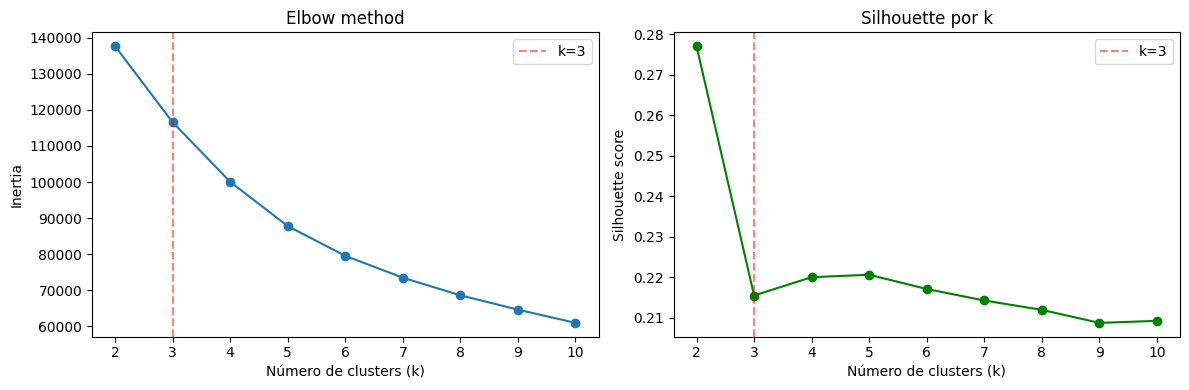


Silhouette scores:
  k=2: 0.2770
  k=3: 0.2155
  k=4: 0.2200
  k=5: 0.2206
  k=6: 0.2171
  k=7: 0.2143
  k=8: 0.2120
  k=9: 0.2088
  k=10: 0.2093


In [13]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X3_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X3_sc, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3') # esto es porque en el EDA vi tres grupos diferenciados
axes[0].legend()

axes[1].plot(K_range, silhouettes, marker='o', color='green')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette por k')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3')
axes[1].legend()

plt.tight_layout()
plt.show();

print("\nSilhouette scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

No hay un elbow muy marcado y el mejor Silhouette score lo tiene k=2. Los Silhouette score de k=3 a k=6 son super parecidos. Opto por continuar con k=2 y k=3 para ver qué sale.

In [14]:
for k in [2, 3]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    df[f'cluster_k{k}'] = km.fit_predict(X3_sc)
    perfil = np.expm1(df.groupby(f'cluster_k{k}')[cols_clust].mean()) # lo pasamos a exponencial
    print(f"\n── Perfil medio k={k} (escala real) ──")
    print(perfil.round(1))


── Perfil medio k=2 (escala real) ──
            casualties_log  economic_loss_log  response_hours_log  \
cluster_k2                                                          
0                     45.9           516716.5                19.0   
1                      6.3           175724.5                 5.2   

            recovery_days_log  
cluster_k2                     
0                       108.5  
1                        50.7  

── Perfil medio k=3 (escala real) ──
            casualties_log  economic_loss_log  response_hours_log  \
cluster_k3                                                          
0                      3.8            96787.3                 4.6   
1                     49.9           490480.5                21.1   
2                     22.6           539946.0                 9.7   

            recovery_days_log  
cluster_k3                     
0                        70.6  
1                       168.6  
2                        31.8  


k=2 --> dos grupos: uno con muchas muertes, altas pérdidas económicas, muchas horas de respuesta y muchos días de recuperación; otro con pocas muertes, pérdida económica tirando a baja, pocas horas de respuesta y días de respuesta tirando a bajo.  

k=3 --> tres grupos: uno con impacto mínimo y gestión rápida, otro con alto impacto y mala gestión (el grupo problemático) y otro con impacto medio y recuperación muy rápida (interesante: pérdida económica alta pero se recuperan rápido)

decido continuar con k=3

In [15]:
k_optimo = 3

kmeans = KMeans(n_clusters=k_optimo, n_init=10, random_state=42) # KMeans repite 10 veces con centroides iniciales distintos y se queda con el mejor resultado 
df['cluster'] = kmeans.fit_predict(X3_sc) # Guardamos el cluster directamente en el df original para poder hacer los crosstabs con country y disaster_type en el paso 5.

print(f"Silhouette score final (k={k_optimo}): {silhouette_score(X3_sc, df['cluster']):.4f}")
print("\nDistribución de clusters:")
print(df['cluster'].value_counts().sort_index())

Silhouette score final (k=3): 0.2155

Distribución de clusters:
cluster
0    14704
1    19131
2    16135
Name: count, dtype: int64


Los tres clusters están bastante equilibrados. El Silhouette score es bajo, pero probablemente se debe a que los datos son sintéticos y las variables de clustering se generaron con distribuciones solapadas.

In [58]:
# Medias en escala original (no escalada) para interpretar
perfil = df.groupby('cluster')[['casualties_log', 'economic_loss_log',
                                 'response_hours_log', 'recovery_days_log']].mean()

# También en escala real (deshacer el log)
perfil_real = np.expm1(perfil)
perfil_real.columns = ['víctimas', 'pérdida_económica', 'horas_respuesta', 'días_recuperación']

print("Perfil medio por cluster (escala real):")
print(perfil_real.round(1))

Perfil medio por cluster (escala real):
         víctimas  pérdida_económica  horas_respuesta  días_recuperación
cluster                                                                 
0             3.8            96787.3              4.6               70.6
1            49.9           490480.5             21.1              168.6
2            22.6           539946.0              9.7               31.8


Este paso es clave para ponerle nombre a cada cluster. Si el cluster 0 tiene pocas víctimas, poca pérdida económica y responde rápido → perfil de bajo impacto bien gestionado. Si el cluster 2 tiene muchas víctimas y tarda semanas en responder → perfil de alto impacto mal gestionado. Sin esto el clustering es solo números.

Varianza explicada: PC1=48.0%, PC2=25.3%, Total=73.3%


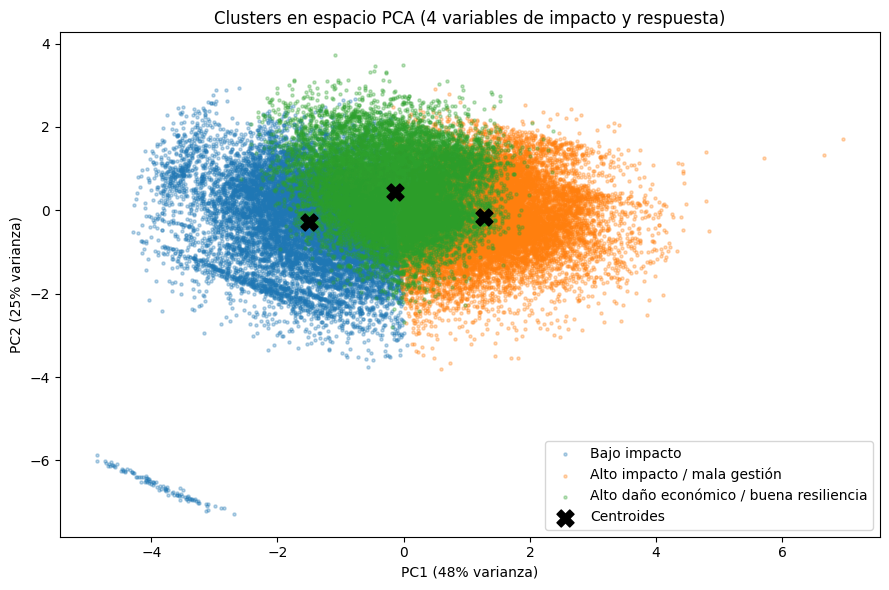

In [64]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X3_sc)

print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={sum(pca.explained_variance_ratio_):.1%}")

colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
nombres_cluster = {0: 'Bajo impacto', 1: 'Alto impacto / mala gestión', 2: 'Alto daño económico / buena resiliencia'}

fig, ax = plt.subplots(figsize=(9, 6))

for c in range(k_optimo):
    mask = df['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colores[c], label=nombres_cluster[c],
               alpha=0.3, s=5)

# Centroides en el espacio PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroides')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza)')
ax.set_title('Clusters en espacio PCA (4 variables de impacto y respuesta)')
ax.legend()
plt.tight_layout()
plt.show();

Los clusters se ordenan de izquierda a derecha de menor a mayor impacto.  
Hay mucho solapamiento entre nubes, especialmente entre naranja y verde en el centro. Esto explica el silhouette de 0.21 — los bordes entre clusters son difusos, no hay separación limpia.  
El grupo aislado abajo a la izquierda en azul (bajo impacto). Son eventos de impacto muy bajo que quedan separados del resto. 

Silhouette scores:
  k=2: 0.2791
  k=3: 0.2932
  k=4: 0.2830
  k=5: 0.2568
  k=6: 0.2542
  k=7: 0.2593
  k=8: 0.2454
  k=9: 0.2275
  k=10: 0.2277

Perfil medio por cluster (escala real aproximada):
             casualties  economic_loss  response_hours  recovery_days
cluster_eda                                                          
0                  70.8      1571495.2            21.6          104.3
1                 116.0      2071856.2            24.2          707.8
2                   8.9       411597.4             7.7           85.0

Varianza explicada: PC1=45.0%, PC2=25.5%


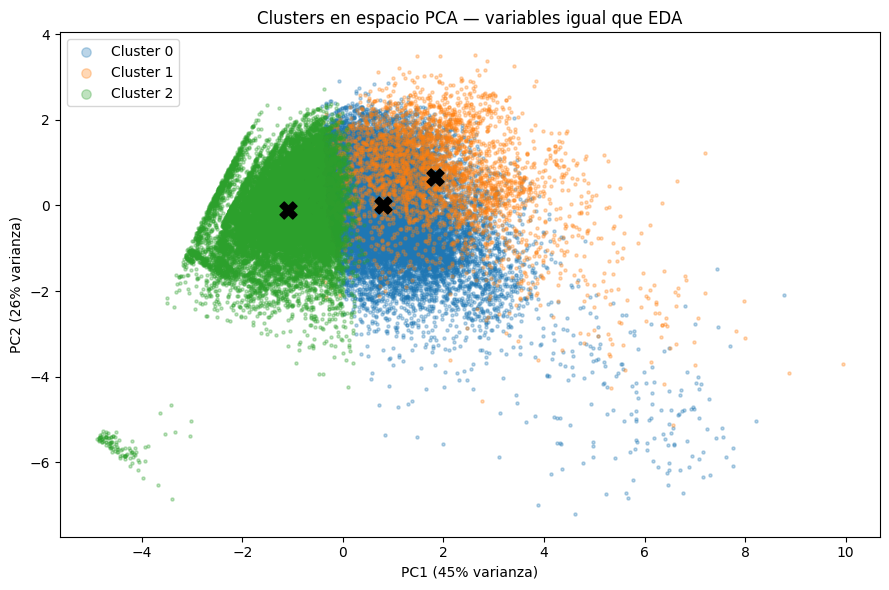

In [65]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Exactamente igual que en el EDA
cols_clustering = ['casualties', 'economic_loss', 'response_hours', 'recovery_days']

df_clust = df[cols_clustering].copy()
df_clust['casualties']    = np.log1p(df['casualties'])
df_clust['economic_loss'] = np.log1p(df['economic_loss'])
# response_hours y recovery_days sin transformar — igual que en el EDA

X3_eda = StandardScaler().fit_transform(df_clust)

# Elbow + silhouette
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X3_eda)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X3_eda, labels))

print("Silhouette scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

# KMeans con k=3
kmeans_eda = KMeans(n_clusters=3, n_init=10, random_state=42)
df['cluster_eda'] = kmeans_eda.fit_predict(X3_eda)

# Perfil medio en escala real
perfil_eda = df.groupby('cluster_eda')[cols_clustering].mean()
print("\nPerfil medio por cluster (escala real aproximada):")
print(perfil_eda.round(1))

# PCA sin random_state — igual que en el EDA
pca_eda = PCA(n_components=2)
X_pca_eda = pca_eda.fit_transform(X3_eda)

print(f"\nVarianza explicada: PC1={pca_eda.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca_eda.explained_variance_ratio_[1]:.1%}")

# Gráfico
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
fig, ax = plt.subplots(figsize=(9, 6))

for c in range(3):
    mask = df['cluster_eda'] == c
    ax.scatter(X_pca_eda[mask, 0], X_pca_eda[mask, 1],
               color=colores[c], alpha=0.3, s=5, label=f'Cluster {c}')

centroides_pca = pca_eda.transform(kmeans_eda.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           c='black', marker='X', s=150, zorder=5)

ax.set_xlabel(f'PC1 ({pca_eda.explained_variance_ratio_[0]:.0%} varianza)')
ax.set_ylabel(f'PC2 ({pca_eda.explained_variance_ratio_[1]:.0%} varianza)')
ax.set_title('Clusters en espacio PCA — variables igual que EDA')
ax.legend(markerscale=3, loc='upper left')
plt.tight_layout()
plt.show()

El cluster 1 es muy interesante — 708 días de recuperación es casi 2 años, muy por encima de los otros. Eso es un perfil de catástrofe prolongada que en la versión con todo en log quedaba diluido.
Conclusión clara: la versión del EDA da mejores resultados, tanto en silhouette como en interpretabilidad de los perfiles. El motivo técnico es que recovery_days sin transformar tiene más varianza y KMeans la usa para separar mejor los clusters en ese eje — que resulta ser el más informativo.

Distribución por tipo de desastre (% por fila):
disaster_type  Cyclone  Drought  Earthquake  Extreme Cold  Extreme Heat  \
cluster                                                                   
0                 0.05     0.09        0.09          0.05          0.11   
1                 0.04     0.13        0.13          0.00          0.07   
2                 0.09     0.09        0.13          0.05          0.14   

disaster_type  Flood  Landslide  Storm Surge  Tornado  Tsunami  \
cluster                                                          
0               0.14       0.18         0.11     0.02     0.02   
1               0.19       0.16         0.11     0.01     0.04   
2               0.13       0.09         0.08     0.02     0.01   

disaster_type  Volcanic Eruption  Wildfire  
cluster                                     
0                           0.04      0.10  
1                           0.03      0.07  
2                           0.03      0.13  

Distribución por pa

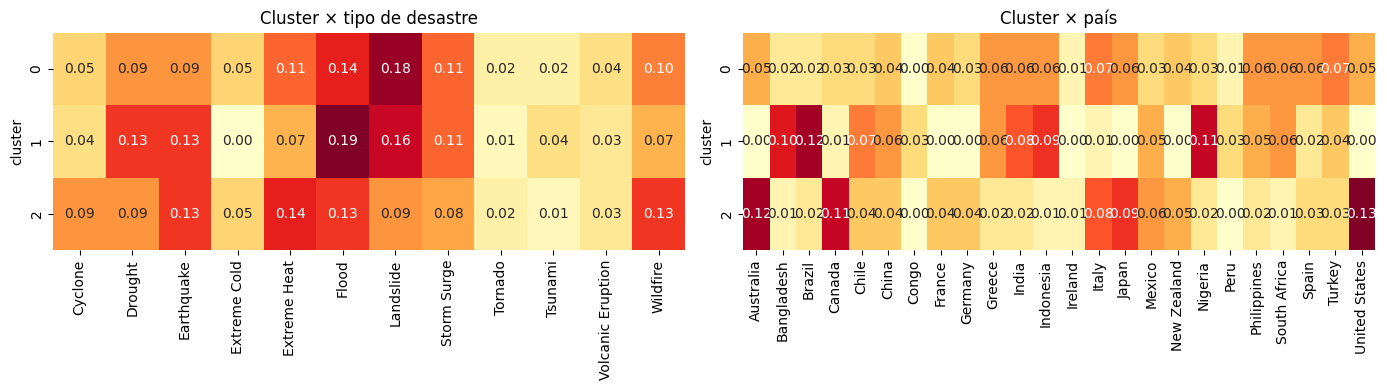

In [ ]:
# Reconstruir disaster_type y country desde las dummies
disaster_cols = [c for c in df.columns if c.startswith('disaster_type_')]
country_cols  = [c for c in df.columns if c.startswith('country_')]

df['disaster_type'] = df[disaster_cols].idxmax(axis=1).str.replace('disaster_type_', '')
df['country']       = df[country_cols].idxmax(axis=1).str.replace('country_', '')

# Cluster × tipo de desastre
ct_tipo = pd.crosstab(df['cluster'], df['disaster_type'], normalize='index').round(2)
print("Distribución por tipo de desastre (% por fila):")
print(ct_tipo)

print()

# Cluster × país (top 8 países más frecuentes para no saturar)
top_paises = df['country'].value_counts().head(8).index
ct_pais = pd.crosstab(df[df['country'].isin(top_paises)]['cluster'],
                       df[df['country'].isin(top_paises)]['country'],
                       normalize='index').round(2)
print("Distribución por país — top 8 (% por fila):")
print(ct_pais)

print()

# Heatmap visual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(ct_tipo, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], cbar=False)
axes[0].set_title('Cluster × tipo de desastre')
axes[0].set_xlabel('')

sns.heatmap(pd.crosstab(df['cluster'], df['country'], normalize='index').round(2),
            annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], cbar=False)
axes[1].set_title('Cluster × país')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

normalize='index' muestra el porcentaje dentro de cada cluster (cada fila suma 1), no el porcentaje total. Así ves si, por ejemplo, el cluster de alto impacto está sobre-representado en ciertos países o tipos de desastre.

Recuerda lo que observaste en el EDA: los colores estaban mezclados en el PCA, así que no esperes que un cluster = un país o un tipo de desastre. Lo interesante es ver si hay tendencias parciales — algunos países pueden aparecer más en el cluster de peor gestión sin dominarlo completamente.

Distribución por tipo de desastre (% por fila):
disaster_type  Cyclone  Drought  Earthquake  Extreme Cold  Extreme Heat  \
cluster_eda                                                               
0                 0.08     0.11        0.13          0.02          0.10   
1                 0.00     0.17        0.22          0.00          0.00   
2                 0.06     0.09        0.09          0.05          0.12   

disaster_type  Flood  Landslide  Storm Surge  Tornado  Tsunami  \
cluster_eda                                                      
0               0.16       0.13         0.10     0.01     0.02   
1               0.28       0.08         0.08     0.00     0.11   
2               0.14       0.17         0.10     0.02     0.02   

disaster_type  Volcanic Eruption  Wildfire  
cluster_eda                                 
0                           0.03      0.11  
1                           0.04      0.01  
2                           0.04      0.10  

Distribución por pa

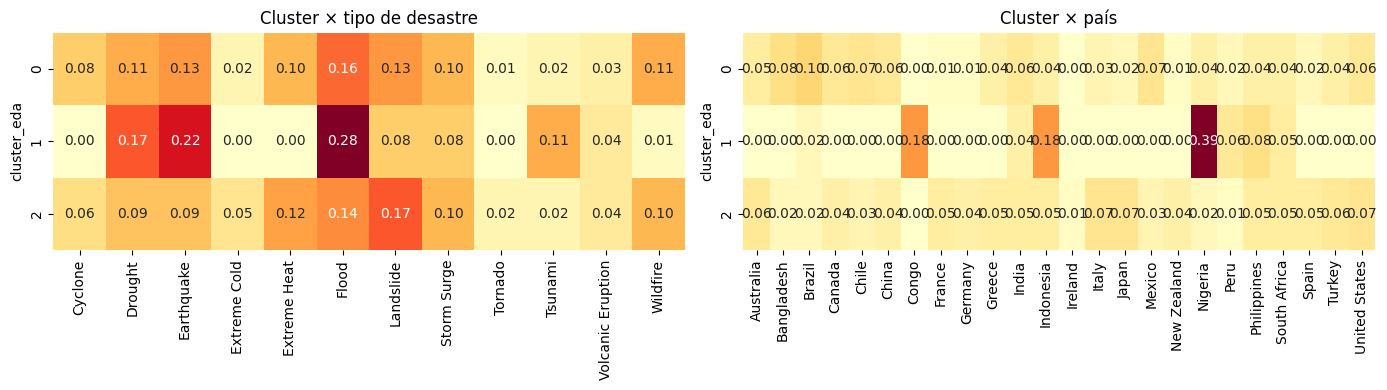

In [72]:
# Reconstruir disaster_type y country desde las dummies
disaster_cols = [c for c in df.columns if c.startswith('disaster_type_')]
country_cols  = [c for c in df.columns if c.startswith('country_')]

df['disaster_type'] = df[disaster_cols].idxmax(axis=1).str.replace('disaster_type_', '')
df['country']       = df[country_cols].idxmax(axis=1).str.replace('country_', '')

# Cluster × tipo de desastre
ct_tipo = pd.crosstab(df['cluster_eda'], df['disaster_type'], normalize='index').round(2)
print("Distribución por tipo de desastre (% por fila):")
print(ct_tipo)

print()

# Cluster × país (top 8 países más frecuentes para no saturar)
top_paises = df['country'].value_counts().head(8).index
ct_pais = pd.crosstab(df[df['country'].isin(top_paises)]['cluster_eda'],
                      df[df['country'].isin(top_paises)]['country'],
                      normalize='index').round(2)
print("Distribución por país — top 8 (% por fila):")
print(ct_pais)

print()

# Heatmap visual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(ct_tipo, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], cbar=False)
axes[0].set_title('Cluster × tipo de desastre')
axes[0].set_xlabel('')

sns.heatmap(pd.crosstab(df['cluster_eda'], df['country'], normalize='index').round(2),
            annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], cbar=False)
axes[1].set_title('Cluster × país')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### DBSCAN

In [18]:
# ─────────────────────────────────────────────
# OBJETIVO 3 — DBSCAN
# ─────────────────────────────────────────────
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

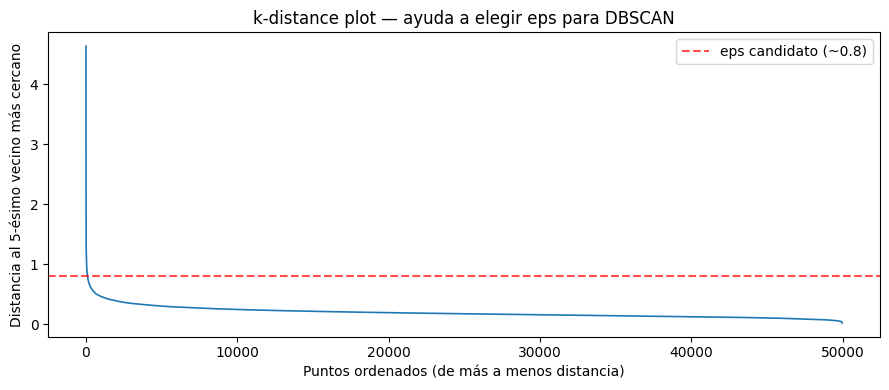

── Mejores combinaciones eps × min_samples ──
 eps  min_samples  n_clusters  pct_ruido  silhouette
 1.0           10           2        0.1      0.6722
 1.2            7           2        0.0      0.6722
 1.2            5           2        0.0      0.6722
 1.2            3           2        0.0      0.6722
 1.0            5           2        0.1      0.6721
 0.9            5           2        0.1      0.6721
 0.9           10           2        0.1      0.6721
 0.9            7           2        0.1      0.6721
 1.0            7           2        0.1      0.6721
 1.2           10           2        0.0      0.6721

── DBSCAN con eps=0.8, min_samples=5 ──
Clusters encontrados: 4
Puntos de ruido:      42 (0.1%)

Distribución:
cluster_dbscan
-1       42
 0    49269
 1      553
 2        7
 3       99
Name: count, dtype: int64

Silhouette score (sin ruido): 0.2843

Varianza explicada: PC1=48.0%, PC2=25.3%, Total=73.3%


C:\Users\cchia\AppData\Local\Temp\ipykernel_2920\520861596.py:161: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', n_clusters_final)


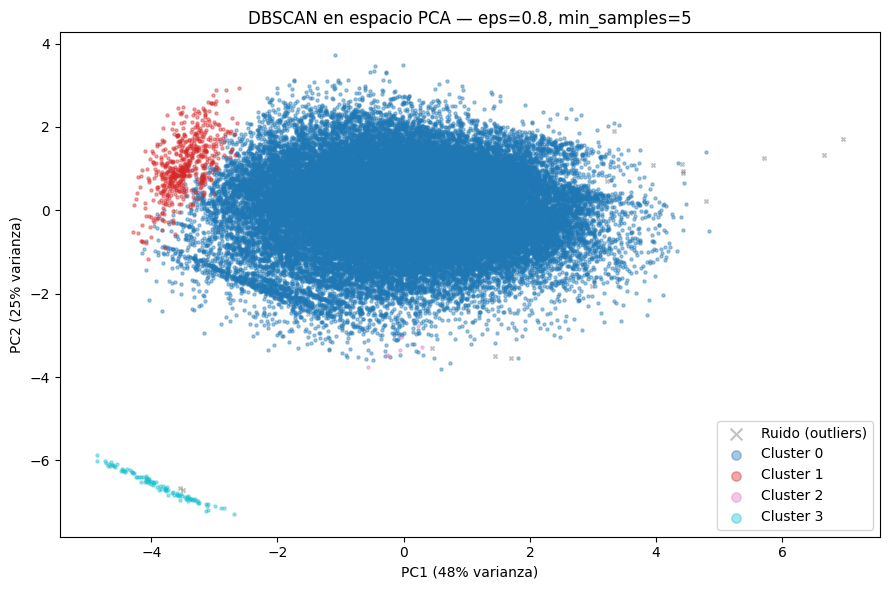

── Perfil medio por cluster DBSCAN (escala real) ──
                víctimas  pérdida_económica_M$  horas_respuesta  \
cluster_dbscan                                                    
0                   19.6              322348.3             10.9   
1                    0.0              278668.8              0.0   
2                    1.1                6612.9            113.9   
3                    0.0                   0.0              8.6   

                días_recuperación  
cluster_dbscan                     
0                            76.8  
1                            47.5  
2                           131.1  
3                            93.9  


KeyError: 'disaster_type'

In [ ]:
# Usamos X3_sc (las 4 variables ya escaladas con StandardScaler):
# casualties_log, economic_loss_log, response_hours_log, recovery_days_log
# Es el mismo array que usamos en KMeans — no hay que reescalar.


# ── PASO 1: k-distance plot para elegir eps ───────────────────────────────────
#
# DBSCAN no tiene un "elbow method" directo, pero hay un truco estándar:
# el k-distance plot. Para cada punto, calcula la distancia a su k-ésimo
# vecino más cercano (k = min_samples - 1). Si ordenas esas distancias de
# mayor a menor, el "codo" de la curva te indica un buen valor de eps:
# a partir de ese punto, los vecinos más cercanos empiezan a estar muy lejos
# → son outliers o ruido. Todo lo que esté por encima del codo quedará
# fuera de cualquier cluster (label = -1).
#
# ¿Por qué min_samples - 1? Porque un core point necesita tener al menos
# min_samples puntos dentro de su radio eps, incluyéndose a sí mismo.
# La distancia al (min_samples - 1)-ésimo vecino es la distancia mínima
# que necesita ese punto para ser core. Si esa distancia está por debajo
# del eps elegido, el punto es core; si no, es borde o ruido.

min_samples = 5  # valor de partida estándar para datasets medianos

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X3_sc)
distancias, _ = nn.kneighbors(X3_sc)

# La columna -1 es la distancia al vecino más lejano de los min_samples
k_distancias = np.sort(distancias[:, -1])[::-1]  # orden descendente

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distancias, linewidth=1.2)
ax.set_xlabel('Puntos ordenados (de más a menos distancia)')
ax.set_ylabel(f'Distancia al {min_samples}-ésimo vecino más cercano')
ax.set_title('k-distance plot — ayuda a elegir eps para DBSCAN')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='eps candidato (~0.8)')
ax.legend()
plt.tight_layout()
plt.show()

# ── INSTRUCCIÓN: observa dónde está el "codo" de la curva.
# Si el codo está en y ≈ 0.8, entonces eps = 0.8 es tu punto de partida.
# Ajusta la línea roja según lo que veas en tu gráfico.


# ── PASO 2: búsqueda de hiperparámetros (eps × min_samples) ──────────────────
#
# Como DBSCAN es muy sensible a eps y min_samples, hacemos una búsqueda
# en rejilla manual. Para cada combinación:
#   - Silhouette score: mide separación entre clusters (ignora los puntos
#     de ruido con label -1, que no pertenecen a ningún cluster).
#   - Porcentaje de ruido: si es muy alto (>30%), el eps es demasiado
#     pequeño o min_samples demasiado grande → clusters demasiado exigentes.
#   - Número de clusters: si sale 1, DBSCAN está metiendo todo en un blob.
#     Si salen 20, eps es demasiado pequeño.
#
# Buscamos la combinación que maximice silhouette score con un % de ruido
# razonable (<25%) y al menos 2 clusters.

eps_valores      = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2]
min_samples_vals = [3, 5, 7, 10]

resultados_dbscan = []

for eps in eps_valores:
    for ms in min_samples_vals:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X3_sc)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido    = (labels == -1).sum()
        pct_ruido  = n_ruido / len(labels) * 100
        
        # Silhouette solo tiene sentido con ≥2 clusters y al menos
        # un punto no-ruido. Si no se cumple, guardamos NaN.
        if n_clusters >= 2 and (labels != -1).sum() > 0:
            # silhouette_score solo evalúa puntos con label != -1
            mask_no_ruido = labels != -1
            sil = silhouette_score(X3_sc[mask_no_ruido], labels[mask_no_ruido])
        else:
            sil = np.nan
        
        resultados_dbscan.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'pct_ruido': round(pct_ruido, 1),
            'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan
        })

df_res = pd.DataFrame(resultados_dbscan)

# Filtrar candidatos razonables: ≥2 clusters, ruido <25%
candidatos = df_res[
    (df_res['n_clusters'] >= 2) &
    (df_res['pct_ruido'] < 25)
].sort_values('silhouette', ascending=False)

print("── Mejores combinaciones eps × min_samples ──")
print(candidatos.head(10).to_string(index=False))

In [19]:
# ── PASO 3: DBSCAN con los hiperparámetros elegidos ──────────────────────────
#
# Sustituye eps_optimo y ms_optimo según lo que hayas visto en el
# k-distance plot y en la tabla de candidatos del paso 2.
# Valores de partida razonables para este dataset escalado: eps=0.8, ms=5.

eps_optimo = 0.8   # ← ajusta según el codo de tu k-distance plot
ms_optimo  = 5     # ← ajusta según la tabla de candidatos

dbscan = DBSCAN(eps=eps_optimo, min_samples=ms_optimo)
df['cluster_dbscan'] = dbscan.fit_predict(X3_sc)

n_clusters_final = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_ruido_final    = (df['cluster_dbscan'] == -1).sum()

print(f"\n── DBSCAN con eps={eps_optimo}, min_samples={ms_optimo} ──")
print(f"Clusters encontrados: {n_clusters_final}")
print(f"Puntos de ruido:      {n_ruido_final} ({n_ruido_final/len(df)*100:.1f}%)")
print(f"\nDistribución:\n{df['cluster_dbscan'].value_counts().sort_index()}")
# El label -1 son los outliers/ruido, no un cluster real.

# Silhouette solo sobre puntos no-ruido
mask_no_ruido = df['cluster_dbscan'] != -1
if n_clusters_final >= 2:
    sil_final = silhouette_score(X3_sc[mask_no_ruido], df['cluster_dbscan'][mask_no_ruido])
    print(f"\nSilhouette score (sin ruido): {sil_final:.4f}")
else:
    print("\nMenos de 2 clusters — ajusta eps o min_samples.")


── DBSCAN con eps=0.8, min_samples=5 ──
Clusters encontrados: 4
Puntos de ruido:      42 (0.1%)

Distribución:
cluster_dbscan
-1       42
 0    49269
 1      553
 2        7
 3       99
Name: count, dtype: int64

Silhouette score (sin ruido): 0.2843


In [ ]:
# ── PASO 4: visualización PCA ─────────────────────────────────────────────────
#
# Igual que con KMeans: comprimimos a 2 dimensiones con PCA para visualizar.
# Los outliers (label -1) los pintamos en gris oscuro con una 'x' para
# distinguirlos claramente de los clusters reales.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X3_sc)

print(f"\nVarianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={sum(pca.explained_variance_ratio_):.1%}")

labels_dbscan = df['cluster_dbscan'].values
cluster_ids   = sorted(set(labels_dbscan))

# Paleta: ruido en gris, clusters en colores
cmap    = plt.cm.get_cmap('tab10', n_clusters_final)
colores = {cid: cmap(i) for i, cid in enumerate(c for c in cluster_ids if c != -1)}
colores[-1] = (0.4, 0.4, 0.4, 0.5)  # gris semitransparente para ruido

fig, ax = plt.subplots(figsize=(9, 6))

for cid in cluster_ids:
    mask = labels_dbscan == cid
    nombre = f'Cluster {cid}' if cid != -1 else 'Ruido (outliers)'
    marker = 'o' if cid != -1 else 'x'
    size   = 5   if cid != -1 else 8
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colores[cid], label=nombre,
               alpha=0.4, s=size, marker=marker)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza)')
ax.set_title(f'DBSCAN en espacio PCA — eps={eps_optimo}, min_samples={ms_optimo}')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


# ── PASO 5: perfil medio por cluster ─────────────────────────────────────────
#
# Solo sobre los puntos que SÍ pertenecen a un cluster (excluimos ruido).
# np.expm1() deshace el log para interpretar en escala real.

df_sin_ruido = df[df['cluster_dbscan'] != -1].copy()

perfil_dbscan = df_sin_ruido.groupby('cluster_dbscan')[cols_clust].mean()
perfil_real   = np.expm1(perfil_dbscan)
perfil_real.columns = ['víctimas', 'pérdida_económica_M$', 'horas_respuesta', 'días_recuperación']

print("── Perfil medio por cluster DBSCAN (escala real) ──")
print(perfil_real.round(1))




Distribución por tipo de desastre (% por fila):
disaster_type   Cyclone  Drought  Earthquake  Extreme Cold  Extreme Heat  \
cluster_dbscan                                                             
0                  0.06     0.11        0.12          0.03          0.10   
1                  0.02     0.09        0.10          0.05          0.09   
2                  0.00     0.00        0.00          0.00          0.14   
3                  0.07     0.06        0.12          0.09          0.09   

disaster_type   Flood  Landslide  Storm Surge  Tornado  Tsunami  \
cluster_dbscan                                                    
0                0.16       0.14         0.10     0.02     0.03   
1                0.24       0.19         0.10     0.01     0.01   
2                0.43       0.14         0.14     0.14     0.00   
3                0.22       0.08         0.15     0.00     0.01   

disaster_type   Volcanic Eruption  Wildfire  
cluster_dbscan                               

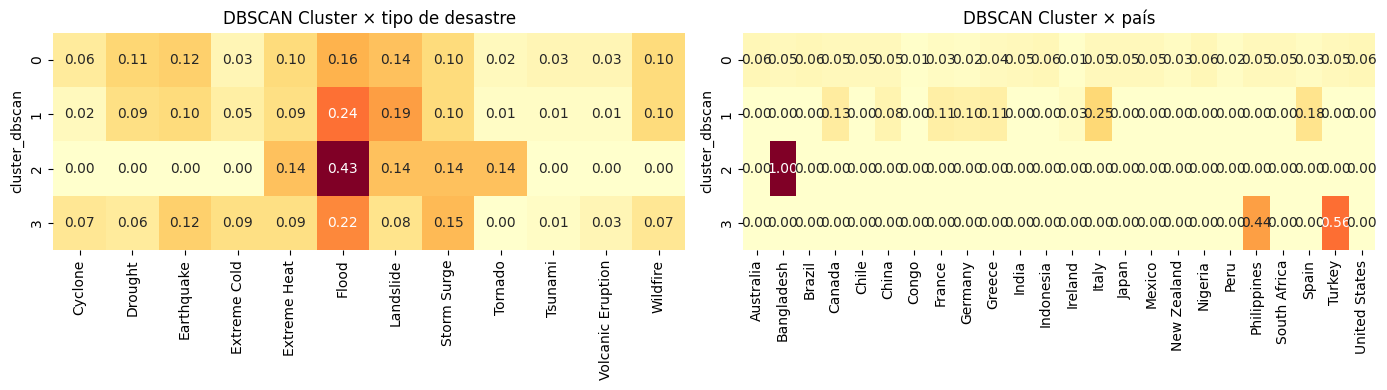

Usando columna KMeans: 'cluster'

── Comparación KMeans vs DBSCAN ──
                Método  Clusters  % ruido  Silhouette
          KMeans (k=3)         3      0.0      0.2155
DBSCAN (eps=0.8, ms=5)         4      0.1      0.2843


In [50]:
# ── PASO 6: crosstabs con país y tipo de desastre ────────────────────────────

# Reconstruir disaster_type y country desde columnas one-hot en df_sin_ruido
disaster_cols = [c for c in df_sin_ruido.columns if c.startswith('disaster_type_')]
country_cols  = [c for c in df_sin_ruido.columns if c.startswith('country_')]

df_sin_ruido = df_sin_ruido.copy()  # evitar SettingWithCopyWarning
df_sin_ruido['disaster_type'] = (
    df_sin_ruido[disaster_cols]
    .idxmax(axis=1)
    .str.replace('disaster_type_', '', regex=False)
)

df_sin_ruido['country'] = (
    df_sin_ruido[country_cols]
    .idxmax(axis=1)
    .str.replace('country_', '', regex=False)
)

ct_tipo = pd.crosstab(df_sin_ruido['cluster_dbscan'],
                      df_sin_ruido['disaster_type'],
                      normalize='index').round(2)
print("\nDistribución por tipo de desastre (% por fila):")
print(ct_tipo)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(ct_tipo, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], cbar=False)
axes[0].set_title('DBSCAN Cluster × tipo de desastre')
axes[0].set_xlabel('')

ct_pais = pd.crosstab(df_sin_ruido['cluster_dbscan'],
                      df_sin_ruido['country'],
                      normalize='index').round(2)
sns.heatmap(ct_pais, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], cbar=False)
axes[1].set_title('DBSCAN Cluster × país')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


# ── PASO 7: comparación KMeans vs DBSCAN ─────────────────────────────────────

# Detectar automáticamente el nombre de la columna KMeans en df
# (puede llamarse 'cluster', 'cluster_k3', 'cluster_kmeans', etc.)
# Buscar columna KMeans: primero 'cluster' exacto, luego cualquier cluster_*
# excluyendo dbscan y las columnas k2/k3 del loop intermedio
kmeans_col = next(
    (c for c in ['cluster', 'cluster_eda', 'cluster_k3', 'cluster_k2']
     if c in df.columns),
    None
)
if kmeans_col is None:
    kmeans_col = next(
        (c for c in df.columns if c.startswith('cluster') and 'dbscan' not in c),
        None
    )
if kmeans_col is None:
    raise ValueError("No se encontró columna de clusters KMeans en df. "
                     f"Columnas disponibles: {list(df.columns)}")
print(f"Usando columna KMeans: '{kmeans_col}'")

resumen_comparacion = pd.DataFrame({
    'Método':      ['KMeans (k=3)', f'DBSCAN (eps={eps_optimo}, ms={ms_optimo})'],
    'Clusters':    [3, n_clusters_final],
    '% ruido':     [0.0, round(n_ruido_final / len(df) * 100, 1)],
    'Silhouette':  [
        round(silhouette_score(X3_sc, df[kmeans_col]), 4),
        round(sil_final, 4) if n_clusters_final >= 2 else np.nan
    ]
})

print("\n── Comparación KMeans vs DBSCAN ──")
print(resumen_comparacion.to_string(index=False))

### UMAP

PCA es lineal — comprime maximizando varianza pero no captura relaciones no lineales. Con solo 4 variables y un silhouette de 0.21, es probable que la separación real entre clusters sea no lineal y PCA la esté "aplanando".
UMAP preserva mejor la estructura local (vecinos cercanos) y también algo de la global, por lo que los clusters suelen verse más separados y limpios en el scatter plot.

c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding UMAP generado: (49970, 2)
Rango umap_1: [-5.16, 18.84]
Rango umap_2: [-11.09, 16.07]


C:\Users\cchia\AppData\Local\Temp\ipykernel_35664\4007927952.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db = plt.cm.get_cmap('tab10', n_clusters_db)


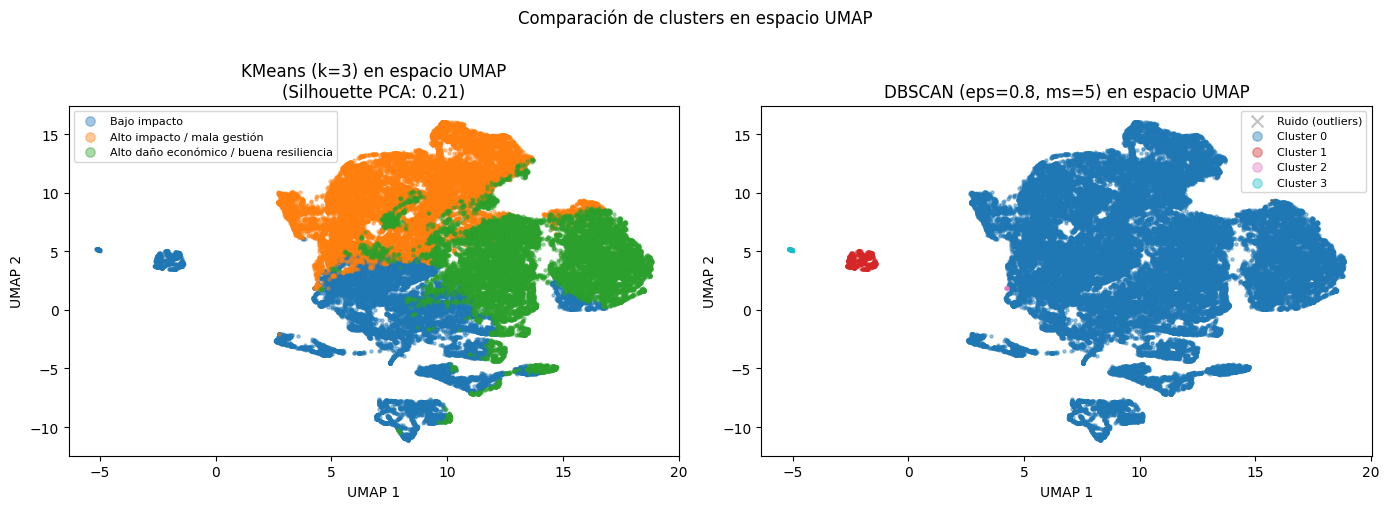

Silhouette KMeans en espacio UMAP:  0.3208
Silhouette KMeans en espacio orig.: 0.2155

Silhouette DBSCAN en espacio UMAP:  0.0054
Silhouette DBSCAN en espacio orig.: 0.2843


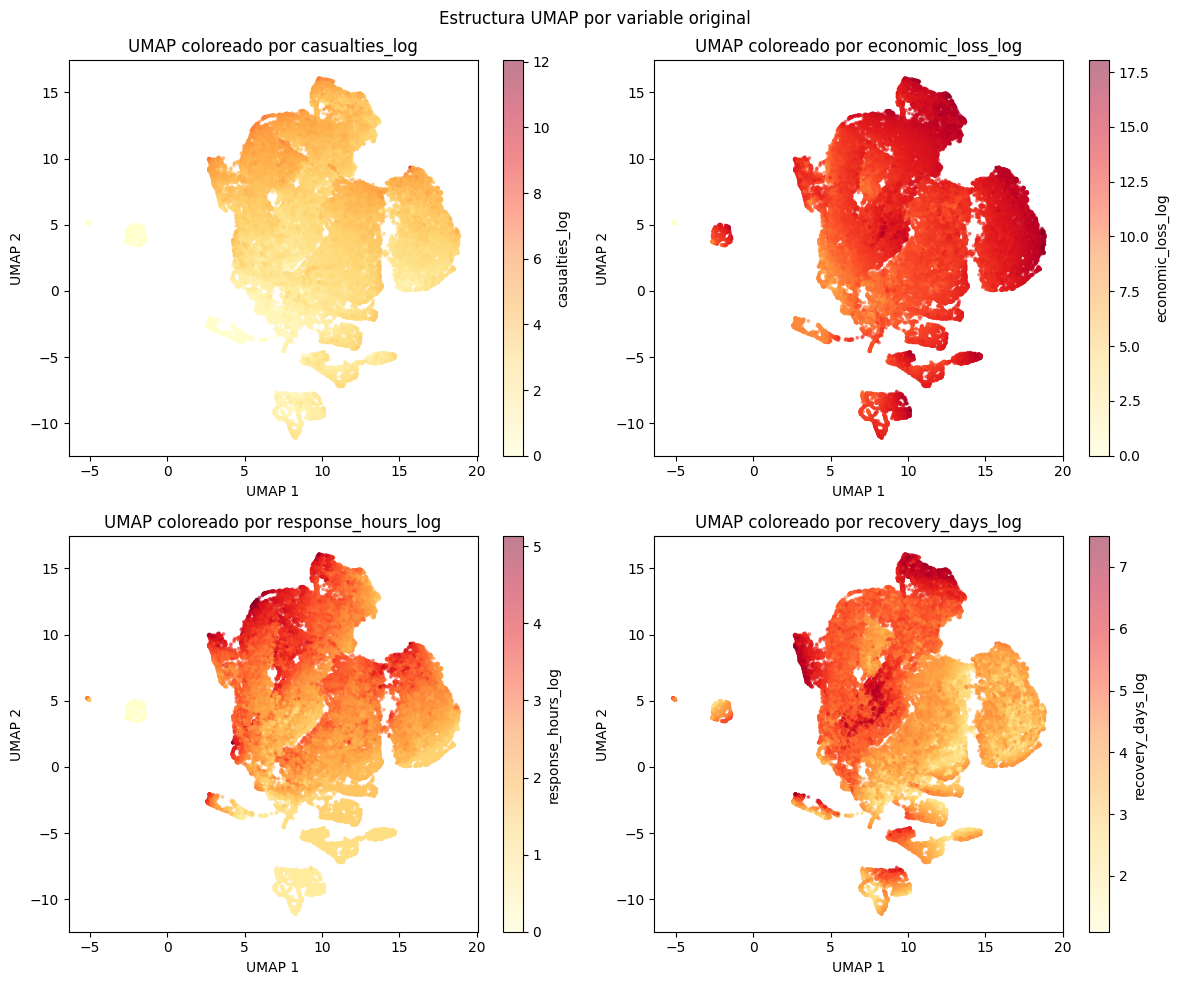


── Resumen comparativo final ──
                Método          Espacio  Clusters  % ruido  Silhouette
          KMeans (k=3) Original (X3_sc)         3      0.0      0.2155
DBSCAN (eps=0.8, ms=5) Original (X3_sc)         4      0.1      0.2843
          KMeans (k=3)             UMAP         3      0.0      0.3208
                DBSCAN             UMAP         4      0.1      0.0054


In [20]:
# ── UMAP: reducción dimensional no lineal ────────────────────────────────────
# !pip install umap-learn  # descomenta si no lo tienes instalado
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score

# ── PASO 1: ajustar UMAP sobre los datos escalados ───────────────────────────
# X3_sc son las 4 variables ya escaladas con StandardScaler:
# casualties_log, economic_loss_log, response_hours_log, recovery_days_log
# — el mismo array que usaste en KMeans y DBSCAN.

reducer = umap.UMAP(
    n_neighbors=15,   # controla el equilibrio local/global; prueba 30-50 para más estructura global
    min_dist=0.1,     # distancia mínima entre puntos en el embedding; menor = clusters más apretados
    n_components=2,   # 2D para visualización
    random_state=42
)

X_umap = reducer.fit_transform(X3_sc)

df['umap_1'] = X_umap[:, 0]
df['umap_2'] = X_umap[:, 1]

print(f"Embedding UMAP generado: {X_umap.shape}")
print(f"Rango umap_1: [{X_umap[:, 0].min():.2f}, {X_umap[:, 0].max():.2f}]")
print(f"Rango umap_2: [{X_umap[:, 1].min():.2f}, {X_umap[:, 1].max():.2f}]")


# ── PASO 2: visualizar los clusters KMeans y DBSCAN en el espacio UMAP ───────
# El objetivo es ver si los clusters que ya tienes (KMeans k=3 y DBSCAN)
# se separan mejor en UMAP que en PCA.
# Si los colores forman islas bien definidas → UMAP está revelando estructura
# que PCA aplana. Si siguen mezclados → los clusters realmente se solapan.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── KMeans k=3 en UMAP ──
# Detectar automáticamente la columna KMeans (igual que en la celda DBSCAN)
kmeans_col = next(
    (c for c in ['cluster', 'cluster_eda', 'cluster_k3'] if c in df.columns), None
)

nombres_cluster = {
    0: 'Bajo impacto',
    1: 'Alto impacto / mala gestión',
    2: 'Alto daño económico / buena resiliencia'
}
colores_kmeans = ['#1f77b4', '#ff7f0e', '#2ca02c']

for c in sorted(df[kmeans_col].unique()):
    mask = df[kmeans_col] == c
    axes[0].scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        color=colores_kmeans[c],
        label=nombres_cluster.get(c, f'Cluster {c}'),
        alpha=0.4, s=5
    )

axes[0].set_title(f'KMeans (k=3) en espacio UMAP\n(Silhouette PCA: 0.21)')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(markerscale=3, fontsize=8)

# ── DBSCAN en UMAP ──
labels_dbscan = df['cluster_dbscan'].values
cluster_ids_db = sorted(set(labels_dbscan))
n_clusters_db = len([c for c in cluster_ids_db if c != -1])

cmap_db = plt.cm.get_cmap('tab10', n_clusters_db)
colores_db = {cid: cmap_db(i) for i, cid in enumerate(c for c in cluster_ids_db if c != -1)}
colores_db[-1] = (0.4, 0.4, 0.4, 0.4)  # gris para ruido

for cid in cluster_ids_db:
    mask = labels_dbscan == cid
    nombre = f'Cluster {cid}' if cid != -1 else 'Ruido (outliers)'
    marker = 'o' if cid != -1 else 'x'
    size   = 5   if cid != -1 else 8
    axes[1].scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        color=colores_db[cid], label=nombre,
        alpha=0.4, s=size, marker=marker
    )

axes[1].set_title(f'DBSCAN (eps={eps_optimo}, ms={ms_optimo}) en espacio UMAP')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(markerscale=3, fontsize=8)

plt.suptitle('Comparación de clusters en espacio UMAP', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


# ── PASO 3: silhouette score en el espacio UMAP ───────────────────────────────
# El silhouette calculado antes (0.21) usaba el espacio original escalado (X3_sc).
# Aquí lo recalculamos usando las coordenadas UMAP como espacio de distancias.
# Si sube significativamente → UMAP ha separado mejor los clusters;
# si baja → PCA era más fiel a la geometría original.

sil_umap_kmeans = silhouette_score(X_umap, df[kmeans_col])
print(f"Silhouette KMeans en espacio UMAP:  {sil_umap_kmeans:.4f}")
print(f"Silhouette KMeans en espacio orig.: {silhouette_score(X3_sc, df[kmeans_col]):.4f}")

mask_no_ruido_umap = df['cluster_dbscan'] != -1
if n_clusters_db >= 2:
    sil_umap_dbscan = silhouette_score(
        X_umap[mask_no_ruido_umap],
        df['cluster_dbscan'][mask_no_ruido_umap]
    )
    print(f"\nSilhouette DBSCAN en espacio UMAP:  {sil_umap_dbscan:.4f}")
    print(f"Silhouette DBSCAN en espacio orig.: {silhouette_score(X3_sc[mask_no_ruido_umap], df['cluster_dbscan'][mask_no_ruido_umap]):.4f}")


# ── PASO 4: colorear por variables originales ─────────────────────────────────
# Para entender qué captura cada eje UMAP, pintamos los puntos según
# el valor de cada variable original. Esto confirma los nombres de cluster:
# si la zona "alto impacto" de KMeans coincide con los valores más altos
# de casualties_log y recovery_days_log, los nombres tienen sentido.

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), cols_clust):
    sc = ax.scatter(
        X_umap[:, 0], X_umap[:, 1],
        c=df[col], cmap='YlOrRd', alpha=0.5, s=3
    )
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(f'UMAP coloreado por {col}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.suptitle('Estructura UMAP por variable original', fontsize=12)
plt.tight_layout()
plt.show()


# ── PASO 5: tabla resumen final ───────────────────────────────────────────────
resumen_final = pd.DataFrame({
    'Método':        ['KMeans (k=3)', f'DBSCAN (eps={eps_optimo}, ms={ms_optimo})', 'KMeans (k=3)', f'DBSCAN'],
    'Espacio':       ['Original (X3_sc)', 'Original (X3_sc)', 'UMAP', 'UMAP'],
    'Clusters':      [3, n_clusters_db, 3, n_clusters_db],
    '% ruido':       [0.0, round((df['cluster_dbscan'] == -1).sum() / len(df) * 100, 1),
                      0.0, round((df['cluster_dbscan'] == -1).sum() / len(df) * 100, 1)],
    'Silhouette':    [
        round(silhouette_score(X3_sc, df[kmeans_col]), 4),
        round(silhouette_score(X3_sc[mask_no_ruido_umap], df['cluster_dbscan'][mask_no_ruido_umap]), 4) if n_clusters_db >= 2 else np.nan,
        round(sil_umap_kmeans, 4),
        round(sil_umap_dbscan, 4) if n_clusters_db >= 2 else np.nan
    ]
})

print("\n── Resumen comparativo final ──")
print(resumen_final.to_string(index=False))

In [ ]:
# !pip install hdbscan

   ---------------------------------------- 0.0/686.0 kB ? eta -:--:--
    --------------------------------------- 10.2/686.0 kB ? eta -:--:--
   -- ------------------------------------ 41.0/686.0 kB 495.5 kB/s eta 0:00:02
   ----- ---------------------------------- 92.2/686.0 kB 1.1 MB/s eta 0:00:01
   ------ ------------------------------- 112.6/686.0 kB 656.4 kB/s eta 0:00:01
   ----------- ---------------------------- 204.8/686.0 kB 1.1 MB/s eta 0:00:01
   ----------- ---------------------------- 204.8/686.0 kB 1.1 MB/s eta 0:00:01
   ---------------------- ----------------- 389.1/686.0 kB 1.3 MB/s eta 0:00:01
   --------------------------- ------------ 471.0/686.0 kB 1.3 MB/s eta 0:00:01
   ------------------------------- -------- 532.5/686.0 kB 1.4 MB/s eta 0:00:01
   ----------------------------------- ---- 614.4/686.0 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 686.0/686.0 kB 1.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


── Mejores combinaciones min_cluster_size × min_samples ──
 min_cluster_size  min_samples  n_clusters  pct_ruido  silhouette
                5            5           2        0.0      0.6721
                5            5           2        0.0      0.6721
                5           10           2        0.0      0.6721
                5           15           2        0.0      0.6721
               10           10           2        0.0      0.6721
               10            5           2        0.0      0.6721
               10           10           2        0.0      0.6721
               10           15           2        0.0      0.6721
               20           20           2        0.0      0.6721
               20            5           2        0.0      0.6721

── HDBSCAN con min_cluster_size=200, min_samples=50 ──
Clusters encontrados: 2
Puntos de ruido:      1436 (2.9%)

Distribución:
cluster_hdbscan
-1     1436
 0      479
 1    48055
Name: count, dtype: int64

Silhoue

C:\Users\cchia\AppData\Local\Temp\ipykernel_35664\2689536363.py:141: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_hdb    = plt.cm.get_cmap('tab10', n_clusters_hdb)


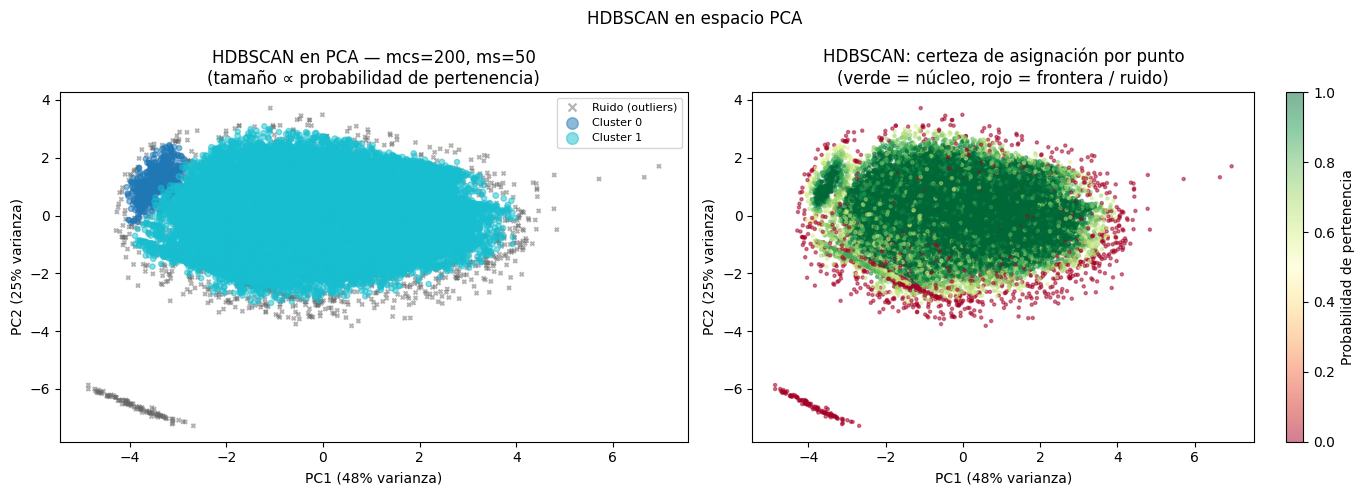

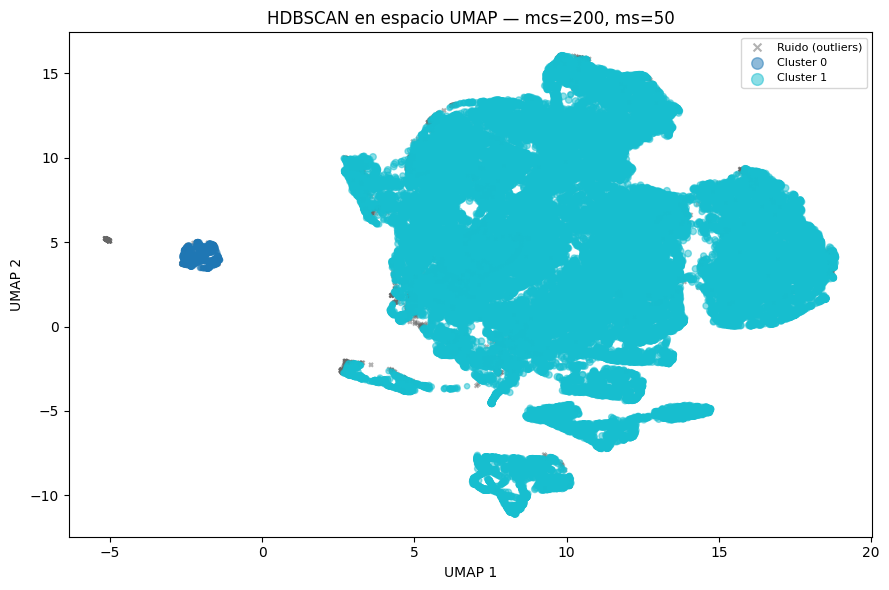

── Perfil medio por cluster HDBSCAN (escala real) ──
                 víctimas  pérdida_económica_M$  horas_respuesta  \
cluster_hdbscan                                                    
0                     0.0              285219.7              0.0   
1                    19.7              334365.7             10.8   

                 días_recuperación  
cluster_hdbscan                     
0                             48.6  
1                             76.1  

── Probabilidad media de pertenencia por cluster ──
cluster_hdbscan
0    0.864
1    0.967
Name: hdbscan_prob, dtype: float64

Distribución por tipo de desastre (% por fila):
disaster_type    Cyclone  Drought  Earthquake  Extreme Cold  Extreme Heat  \
cluster_hdbscan                                                             
0                   0.01     0.09        0.10          0.06          0.09   
1                   0.06     0.11        0.12          0.03          0.10   

disaster_type    Flood  Landslide  Storm S

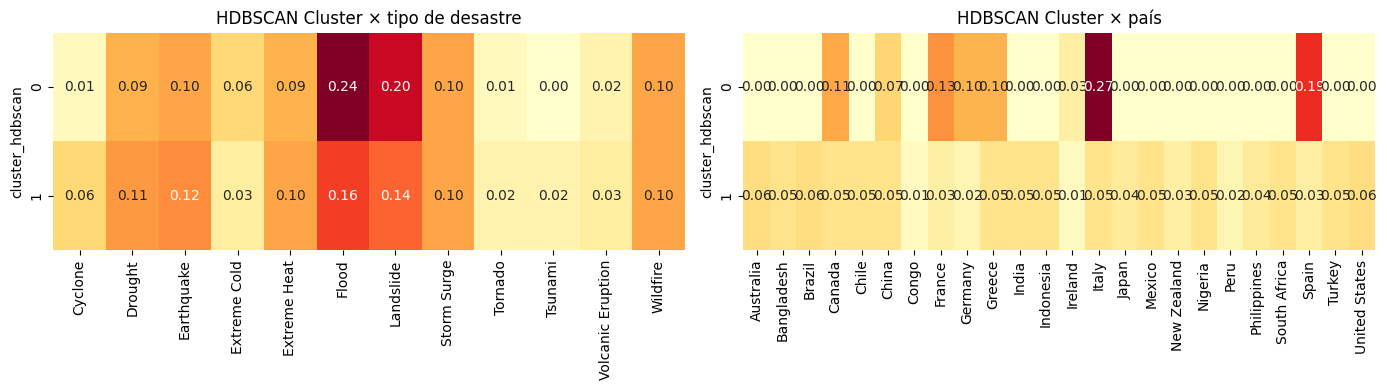


── Comparación KMeans vs DBSCAN vs HDBSCAN ──
                  Método  Clusters  % ruido  Silhouette
            KMeans (k=3)         3      0.0      0.2155
 DBSCAN (eps=0.8, ms=50)         4      0.1      0.2843
HDBSCAN (mcs=200, ms=50)         2      2.9      0.3617


In [ ]:
# ── HDBSCAN: clustering jerárquico basado en densidad ────────────────────────
# HDBSCAN mejora DBSCAN en dos aspectos clave para tu problema:
# 1. No necesitas fijar eps — solo min_cluster_size, que es más intuitivo.
# 2. Permite clusters de densidad variable: el cluster de "alto impacto / mala gestión"
#    puede tener una densidad distinta al de "bajo impacto" y aun así detectarlos bien.
# El silhouette de 0.21 con KMeans sugiere solapamiento y densidades distintas,
# exactamente el escenario donde HDBSCAN suele ganar a DBSCAN.

import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# ── PASO 1: búsqueda de hiperparámetros ──────────────────────────────────────
# HDBSCAN tiene dos parámetros principales:
#   - min_cluster_size: el tamaño mínimo de un cluster para que no se considere ruido.
#     Valores pequeños (5-10) → muchos clusters pequeños.
#     Valores grandes (50-100) → pocos clusters grandes, más ruido.
#   - min_samples: controla cuánto tiene que ser "core" un punto para unirse a un cluster.
#     Por defecto = min_cluster_size. Subirlo hace el algoritmo más conservador (más ruido).
#
# Estrategia: barremos min_cluster_size y min_samples, igual que hicimos con
# eps × min_samples en DBSCAN, y nos quedamos con la combinación que maximice
# silhouette con ruido razonable (<25%) y al menos 2 clusters.

min_cluster_size_vals = [5, 10, 20, 30, 50]
min_samples_vals      = [None, 5, 10, 15]  # None → hereda min_cluster_size

resultados_hdbscan = []

for mcs in min_cluster_size_vals:
    for ms in min_samples_vals:
        ms_real = mcs if ms is None else ms  # HDBSCAN usa mcs si ms=None
        
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric='euclidean',
            cluster_selection_method='eom'  # 'eom' (Excess of Mass) es el default;
                                             # prueba 'leaf' si obtienes demasiados clusters
        )
        labels = clusterer.fit_predict(X3_sc)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido    = (labels == -1).sum()
        pct_ruido  = n_ruido / len(labels) * 100
        
        if n_clusters >= 2 and (labels != -1).sum() > 1:
            mask_no_ruido = labels != -1
            sil = silhouette_score(X3_sc[mask_no_ruido], labels[mask_no_ruido])
        else:
            sil = np.nan
        
        resultados_hdbscan.append({
            'min_cluster_size': mcs,
            'min_samples':      ms_real,
            'n_clusters':       n_clusters,
            'pct_ruido':        round(pct_ruido, 1),
            'silhouette':       round(sil, 4) if not np.isnan(sil) else np.nan
        })

df_res_hdb = pd.DataFrame(resultados_hdbscan)

candidatos_hdb = df_res_hdb[
    (df_res_hdb['n_clusters'] >= 2) &
    (df_res_hdb['pct_ruido'] < 25)
].sort_values('silhouette', ascending=False)

print("── Mejores combinaciones min_cluster_size × min_samples ──")
print(candidatos_hdb.head(10).to_string(index=False))


# ── PASO 2: HDBSCAN con los hiperparámetros elegidos ─────────────────────────
# Sustituye según lo que hayas visto en la tabla de candidatos.
# Punto de partida razonable para este dataset: mcs=20, ms=5.

mcs_optimo = 200   # ← ajusta según la tabla
ms_optimo  = 50    # ← ajusta según la tabla

clusterer_final = hdbscan.HDBSCAN(
    min_cluster_size=50,        # ajusta según cuántos puntos quieres por masa
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='leaf',   # ← clave: captura cada masa por separado
    cluster_selection_epsilon=0.0,     # sin fusionar clusters cercanos
    prediction_data=True
)

df['cluster_hdbscan'] = clusterer_final.fit_predict(X3_sc)

n_clusters_hdb = len(set(df['cluster_hdbscan'])) - (1 if -1 in df['cluster_hdbscan'].values else 0)
n_ruido_hdb    = (df['cluster_hdbscan'] == -1).sum()

print(f"\n── HDBSCAN con min_cluster_size={mcs_optimo}, min_samples={ms_optimo} ──")
print(f"Clusters encontrados: {n_clusters_hdb}")
print(f"Puntos de ruido:      {n_ruido_hdb} ({n_ruido_hdb / len(df) * 100:.1f}%)")
print(f"\nDistribución:\n{df['cluster_hdbscan'].value_counts().sort_index()}")
# El label -1 son outliers — no es un cluster real.

mask_no_ruido_hdb = df['cluster_hdbscan'] != -1
if n_clusters_hdb >= 2:
    sil_hdb = silhouette_score(X3_sc[mask_no_ruido_hdb], df['cluster_hdbscan'][mask_no_ruido_hdb])
    print(f"\nSilhouette score (sin ruido): {sil_hdb:.4f}")
else:
    print("\nMenos de 2 clusters — ajusta min_cluster_size o min_samples.")
    sil_hdb = np.nan


# ── PASO 3: probabilidades de pertenencia ────────────────────────────────────
# Una ventaja exclusiva de HDBSCAN frente a KMeans y DBSCAN: cada punto tiene
# una probabilidad de pertenencia a su cluster (0 = frontera / casi ruido, 1 = núcleo).
# Esto te permite identificar puntos ambiguos que están en la frontera entre clusters,
# algo que KMeans no puede hacer porque asigna cada punto con certeza total.

probs = clusterer_final.probabilities_
df['hdbscan_prob'] = probs

print(f"\nProbabilidad media de pertenencia: {probs[mask_no_ruido_hdb].mean():.3f}")
print(f"Puntos con prob < 0.5 (ambiguos):  {(probs[mask_no_ruido_hdb] < 0.5).sum()}")
print(f"Puntos con prob > 0.9 (núcleo):    {(probs[mask_no_ruido_hdb] > 0.9).sum()}")


# ── PASO 4: visualización PCA ─────────────────────────────────────────────────
# Igual que con KMeans y DBSCAN: comprimimos a 2D con PCA.
# Los outliers en gris, el tamaño de cada punto proporcional a su probabilidad
# de pertenencia — los puntos de frontera aparecen más pequeños.

pca_hdb = PCA(n_components=2, random_state=42)
X_pca_hdb = pca_hdb.fit_transform(X3_sc)

print(f"\nVarianza explicada: PC1={pca_hdb.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca_hdb.explained_variance_ratio_[1]:.1%}, "
      f"Total={sum(pca_hdb.explained_variance_ratio_):.1%}")

labels_hdb = df['cluster_hdbscan'].values
cluster_ids_hdb = sorted(set(labels_hdb))

cmap_hdb    = plt.cm.get_cmap('tab10', n_clusters_hdb)
colores_hdb = {cid: cmap_hdb(i) for i, cid in enumerate(c for c in cluster_ids_hdb if c != -1)}
colores_hdb[-1] = (0.4, 0.4, 0.4, 0.4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Izquierda: coloreado por cluster ──
for cid in cluster_ids_hdb:
    mask   = labels_hdb == cid
    nombre = f'Cluster {cid}' if cid != -1 else 'Ruido (outliers)'
    marker = 'o' if cid != -1 else 'x'
    # tamaño proporcional a la probabilidad; outliers tamaño fijo
    sizes  = (probs[mask] * 20 + 2) if cid != -1 else np.full(mask.sum(), 8)
    axes[0].scatter(
        X_pca_hdb[mask, 0], X_pca_hdb[mask, 1],
        color=colores_hdb[cid], label=nombre,
        alpha=0.5, s=sizes, marker=marker
    )

axes[0].set_xlabel(f'PC1 ({pca_hdb.explained_variance_ratio_[0]:.0%} varianza)')
axes[0].set_ylabel(f'PC2 ({pca_hdb.explained_variance_ratio_[1]:.0%} varianza)')
axes[0].set_title(f'HDBSCAN en PCA — mcs={mcs_optimo}, ms={ms_optimo}\n'
                  f'(tamaño ∝ probabilidad de pertenencia)')
axes[0].legend(markerscale=2, fontsize=8)

# ── Derecha: coloreado por probabilidad de pertenencia ──
sc = axes[1].scatter(
    X_pca_hdb[:, 0], X_pca_hdb[:, 1],
    c=probs, cmap='RdYlGn', alpha=0.5, s=5, vmin=0, vmax=1
)
plt.colorbar(sc, ax=axes[1], label='Probabilidad de pertenencia')
axes[1].set_xlabel(f'PC1 ({pca_hdb.explained_variance_ratio_[0]:.0%} varianza)')
axes[1].set_ylabel(f'PC2 ({pca_hdb.explained_variance_ratio_[1]:.0%} varianza)')
axes[1].set_title('HDBSCAN: certeza de asignación por punto\n'
                  '(verde = núcleo, rojo = frontera / ruido)')

plt.suptitle('HDBSCAN en espacio PCA', fontsize=12)
plt.tight_layout()
plt.show()


# ── PASO 4b: visualización UMAP (si ya tienes X_umap del apartado anterior) ──
# Si ejecutaste la celda de UMAP antes, puedes pintar HDBSCAN también ahí.
# UMAP + HDBSCAN es la combinación canónica: UMAP para visualizar,
# HDBSCAN para clustering — ambos preservan estructura local.

if 'umap_1' in df.columns:
    fig, ax = plt.subplots(figsize=(9, 6))
    for cid in cluster_ids_hdb:
        mask   = labels_hdb == cid
        nombre = f'Cluster {cid}' if cid != -1 else 'Ruido (outliers)'
        marker = 'o' if cid != -1 else 'x'
        sizes  = (probs[mask] * 20 + 2) if cid != -1 else np.full(mask.sum(), 8)
        ax.scatter(
            df.loc[mask, 'umap_1'], df.loc[mask, 'umap_2'],
            color=colores_hdb[cid], label=nombre,
            alpha=0.5, s=sizes, marker=marker
        )
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'HDBSCAN en espacio UMAP — mcs={mcs_optimo}, ms={ms_optimo}')
    ax.legend(markerscale=2, fontsize=8)
    plt.tight_layout()
    plt.show()


# ── PASO 5: perfil medio por cluster ─────────────────────────────────────────
df_sin_ruido_hdb = df[df['cluster_hdbscan'] != -1].copy()

perfil_hdb      = df_sin_ruido_hdb.groupby('cluster_hdbscan')[cols_clust].mean()
perfil_real_hdb = np.expm1(perfil_hdb)
perfil_real_hdb.columns = ['víctimas', 'pérdida_económica_M$', 'horas_respuesta', 'días_recuperación']

print("── Perfil medio por cluster HDBSCAN (escala real) ──")
print(perfil_real_hdb.round(1))

# Probabilidad media por cluster: indica cuánto "confía" el algoritmo en cada uno
print("\n── Probabilidad media de pertenencia por cluster ──")
print(df_sin_ruido_hdb.groupby('cluster_hdbscan')['hdbscan_prob'].mean().round(3))


# ── PASO 6: crosstabs con país y tipo de desastre ────────────────────────────
disaster_cols = [c for c in df_sin_ruido_hdb.columns if c.startswith('disaster_type_')]
country_cols  = [c for c in df_sin_ruido_hdb.columns if c.startswith('country_')]

df_sin_ruido_hdb = df_sin_ruido_hdb.copy()
df_sin_ruido_hdb['disaster_type'] = (
    df_sin_ruido_hdb[disaster_cols]
    .idxmax(axis=1)
    .str.replace('disaster_type_', '', regex=False)
)
df_sin_ruido_hdb['country'] = (
    df_sin_ruido_hdb[country_cols]
    .idxmax(axis=1)
    .str.replace('country_', '', regex=False)
)

ct_tipo_hdb = pd.crosstab(df_sin_ruido_hdb['cluster_hdbscan'],
                           df_sin_ruido_hdb['disaster_type'],
                           normalize='index').round(2)
print("\nDistribución por tipo de desastre (% por fila):")
print(ct_tipo_hdb)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(ct_tipo_hdb, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], cbar=False)
axes[0].set_title('HDBSCAN Cluster × tipo de desastre')
axes[0].set_xlabel('')

ct_pais_hdb = pd.crosstab(df_sin_ruido_hdb['cluster_hdbscan'],
                           df_sin_ruido_hdb['country'],
                           normalize='index').round(2)
sns.heatmap(ct_pais_hdb, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], cbar=False)
axes[1].set_title('HDBSCAN Cluster × país')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


# ── PASO 7: tabla resumen comparativa final ───────────────────────────────────
# Detectar columna KMeans igual que antes
kmeans_col = next(
    (c for c in ['cluster', 'cluster_eda', 'cluster_k3'] if c in df.columns), None
)

resumen_final = pd.DataFrame({
    'Método':     ['KMeans (k=3)', f'DBSCAN (eps={eps_optimo}, ms={ms_optimo})',
                   f'HDBSCAN (mcs={mcs_optimo}, ms={ms_optimo})'],
    'Clusters':   [3, n_clusters_db, n_clusters_hdb],
    '% ruido':    [
        0.0,
        round((df['cluster_dbscan'] == -1).sum() / len(df) * 100, 1),
        round(n_ruido_hdb / len(df) * 100, 1)
    ],
    'Silhouette': [
        round(silhouette_score(X3_sc, df[kmeans_col]), 4),
        round(silhouette_score(
            X3_sc[df['cluster_dbscan'] != -1],
            df['cluster_dbscan'][df['cluster_dbscan'] != -1]
        ), 4),
        round(sil_hdb, 4) if not np.isnan(sil_hdb) else np.nan
    ]
})

print("\n── Comparación KMeans vs DBSCAN vs HDBSCAN ──")
print(resumen_final.to_string(index=False))

In [28]:
from itertools import product

resultados = []

for mcs, ms, epsilon in product(
    [20, 50, 100],          # min_cluster_size
    [3, 5, 10],             # min_samples
    [0.0, 0.3, 0.5, 1.0]   # cluster_selection_epsilon
):
    cl = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        cluster_selection_method='leaf',
        cluster_selection_epsilon=epsilon
    ).fit(X3_sc)
    
    labels = cl.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    pct_ruido  = (labels == -1).sum() / len(labels) * 100
    
    mask = labels != -1
    sil = silhouette_score(X3_sc[mask], labels[mask]) if n_clusters >= 2 and mask.sum() > 1 else np.nan
    
    resultados.append({
        'mcs': mcs, 'ms': ms, 'epsilon': epsilon,
        'n_clusters': n_clusters,
        'pct_ruido': round(pct_ruido, 1),
        'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan
    })

df_res = pd.DataFrame(resultados)

# Filtra por un número de clusters razonable (p.ej. entre 3 y 10)
candidatos = df_res[
    (df_res['n_clusters'] >= 3) &
    (df_res['n_clusters'] <= 10) &
    (df_res['pct_ruido'] < 30)
].sort_values('silhouette', ascending=False)

print(candidatos.head(15).to_string(index=False))

 mcs  ms  epsilon  n_clusters  pct_ruido  silhouette
  20  10      0.5           4        2.3      0.2914
 100  10      0.5           4        2.3      0.2914
  50  10      0.5           4        2.3      0.2914
  20   3      0.5           4        0.7      0.2905
  20   5      0.5           4        1.1      0.2905
  50   5      0.5           4        1.1      0.2905
  50   3      0.5           4        0.7      0.2905
 100   5      0.5           4        1.1      0.2905
 100   3      0.5           4        0.7      0.2905
  50  10      0.3          10       17.5      0.1379
 100  10      0.3           9       17.3      0.1364
 100   5      0.3          10        9.1      0.1257
 100   3      0.3          10        5.8      0.1222


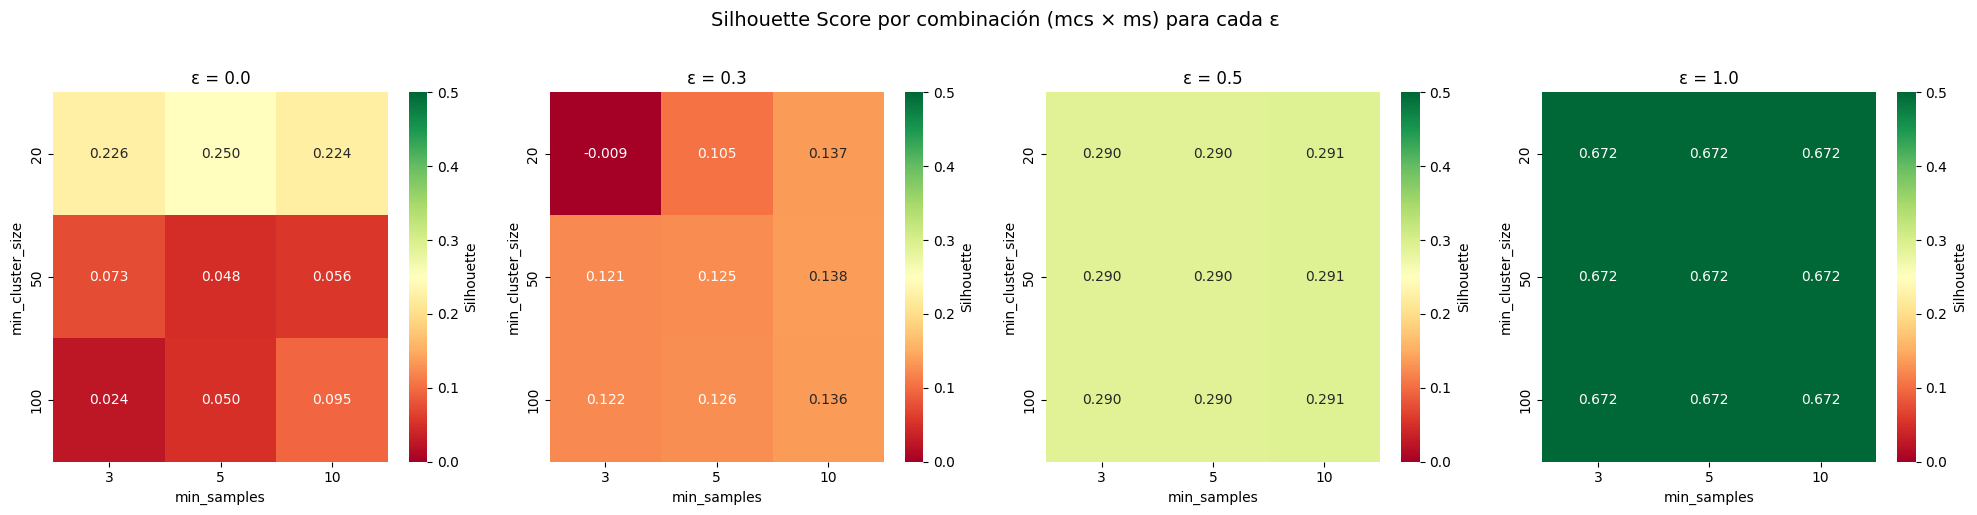

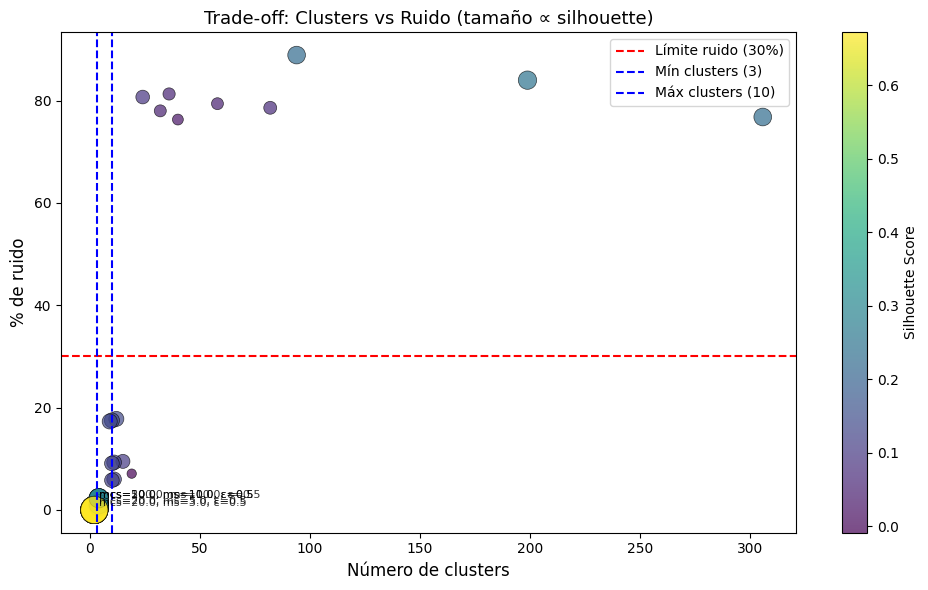

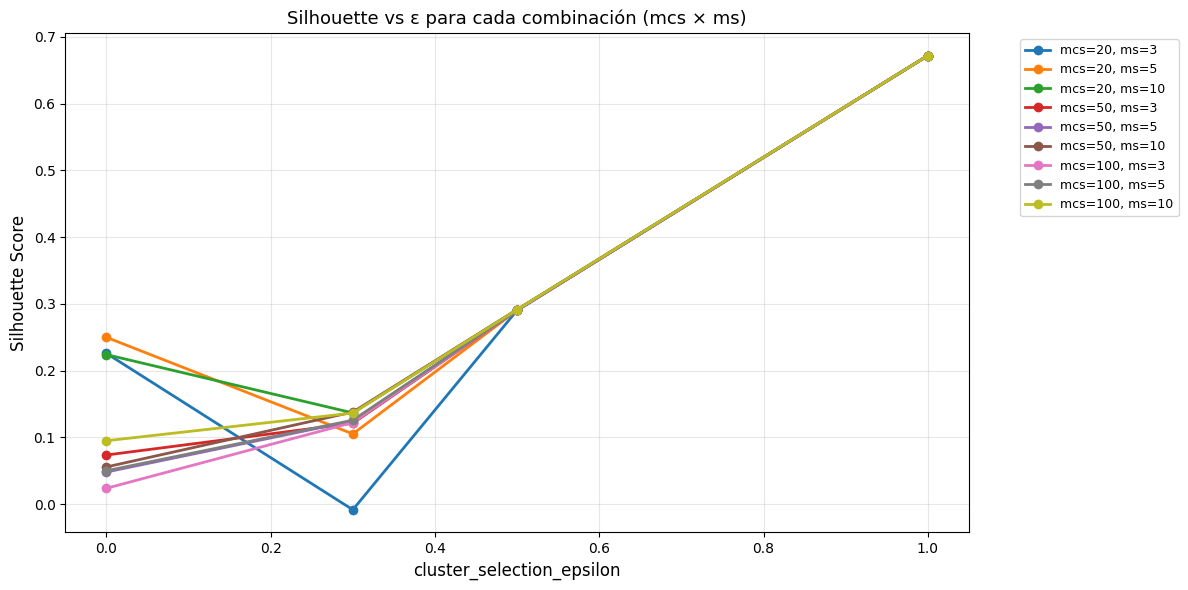


🏆 Mejor combinación: mcs=20.0, ms=10.0, ε=0.5
   Clusters: 4.0, Ruido: 2.3%, Silhouette: 0.2914


ValueError: Epsilon must be a float value greater than or equal to 0!

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── 1. HEATMAP: Silhouette por combinación de hiperparámetros ─────────────
# ✅ CORRECCIÓN: 4 subplots (uno por cada epsilon: 0.0, 0.3, 0.5, 1.0)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

epsilons = [0.0, 0.3, 0.5, 1.0]

for i, epsilon in enumerate(epsilons):
    subset = df_res[df_res['epsilon'] == epsilon]
    
    # ✅ Verificar que hay datos
    if subset.empty:
        axes[i].text(0.5, 0.5, 'Sin datos', ha='center', va='center')
        axes[i].set_title(f'ε = {epsilon}')
        continue
    
    pivot = subset.pivot_table(
        values='silhouette', 
        index='mcs', 
        columns='ms', 
        aggfunc='first'
    )
    
    # ✅ CORRECCIÓN: Usar colormap sin deprecación
    cmap = plt.colormaps['RdYlGn']
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, 
                vmin=0, vmax=0.5, ax=axes[i], cbar_kws={'label': 'Silhouette'})
    axes[i].set_title(f'ε = {epsilon}')
    axes[i].set_xlabel('min_samples')
    axes[i].set_ylabel('min_cluster_size')

plt.suptitle('Silhouette Score por combinación (mcs × ms) para cada ε', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ── 2. GRÁFICO DE BURBUJAS: n_clusters vs pct_ruido ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_res['n_clusters'], 
    df_res['pct_ruido'],
    c=df_res['silhouette'], 
    s=df_res['silhouette'] * 500 + 50,
    cmap='viridis', 
    alpha=0.7, 
    edgecolors='black', 
    linewidth=0.5
)

# Etiquetar los mejores candidatos
candidatos_top = candidatos.head(5)
for _, row in candidatos_top.iterrows():
    ax.annotate(
        f"mcs={row['mcs']}, ms={row['ms']}, ε={row['epsilon']}",
        (row['n_clusters'], row['pct_ruido']),
        fontsize=8, alpha=0.8
    )

ax.axhline(y=30, color='red', linestyle='--', label='Límite ruido (30%)')
ax.axvline(x=3, color='blue', linestyle='--', label='Mín clusters (3)')
ax.axvline(x=10, color='blue', linestyle='--', label='Máx clusters (10)')

ax.set_xlabel('Número de clusters', fontsize=12)
ax.set_ylabel('% de ruido', fontsize=12)
ax.set_title('Trade-off: Clusters vs Ruido (tamaño ∝ silhouette)', fontsize=13)
ax.legend()
plt.colorbar(scatter, ax=ax, label='Silhouette Score')
plt.tight_layout()
plt.show()


# ── 3. LÍNEAS: Silhouette vs epsilon ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

combinaciones = df_res.groupby(['mcs', 'ms'])
for (mcs, ms), group in combinaciones:
    group_sorted = group.sort_values('epsilon')
    ax.plot(group_sorted['epsilon'], group_sorted['silhouette'], 
            marker='o', label=f'mcs={mcs}, ms={ms}', linewidth=2)

ax.set_xlabel('cluster_selection_epsilon', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette vs ε para cada combinación (mcs × ms)', fontsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


🏆 Mejor combinación: mcs=20.0, ms=10.0, ε=0.5
   Clusters: 4.0, Ruido: 2.3%, Silhouette: 0.2914

✅ HDBSCAN entrenado correctamente con ε=0.5
   Clusters encontrados: 4
   Puntos de ruido: 1173 (2.3%)


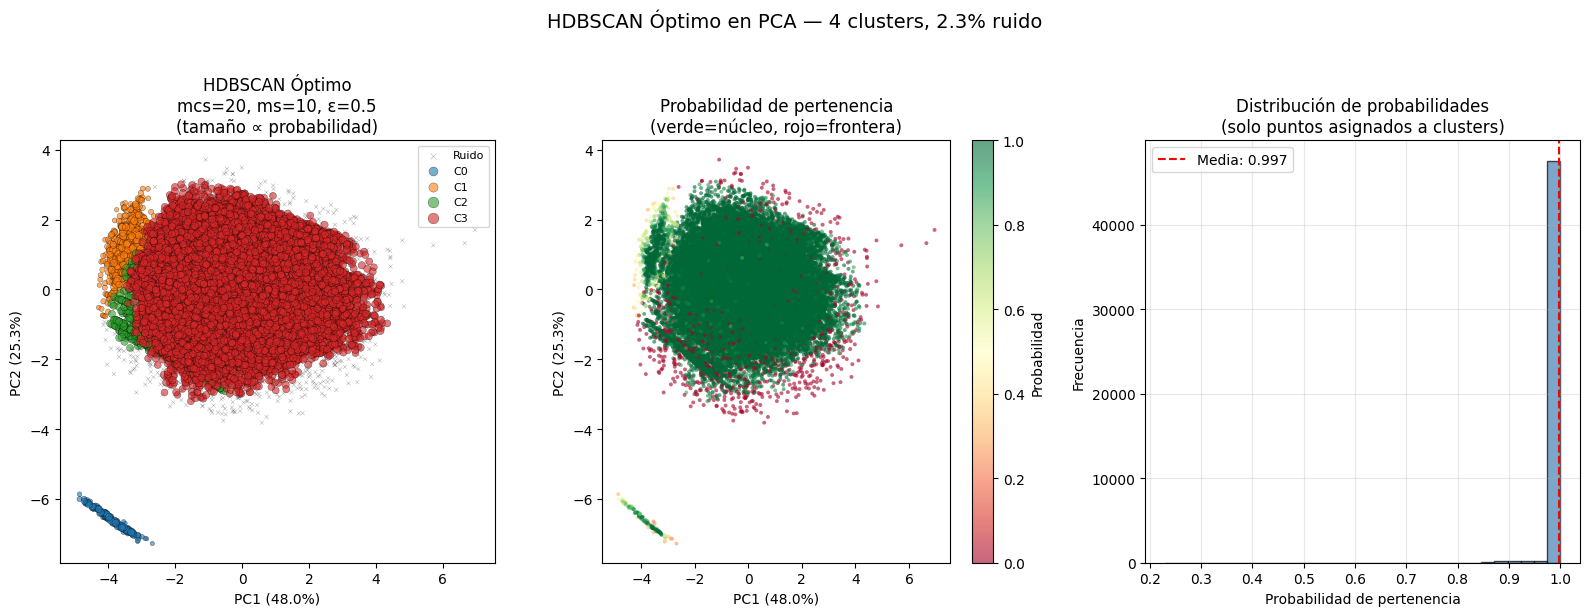

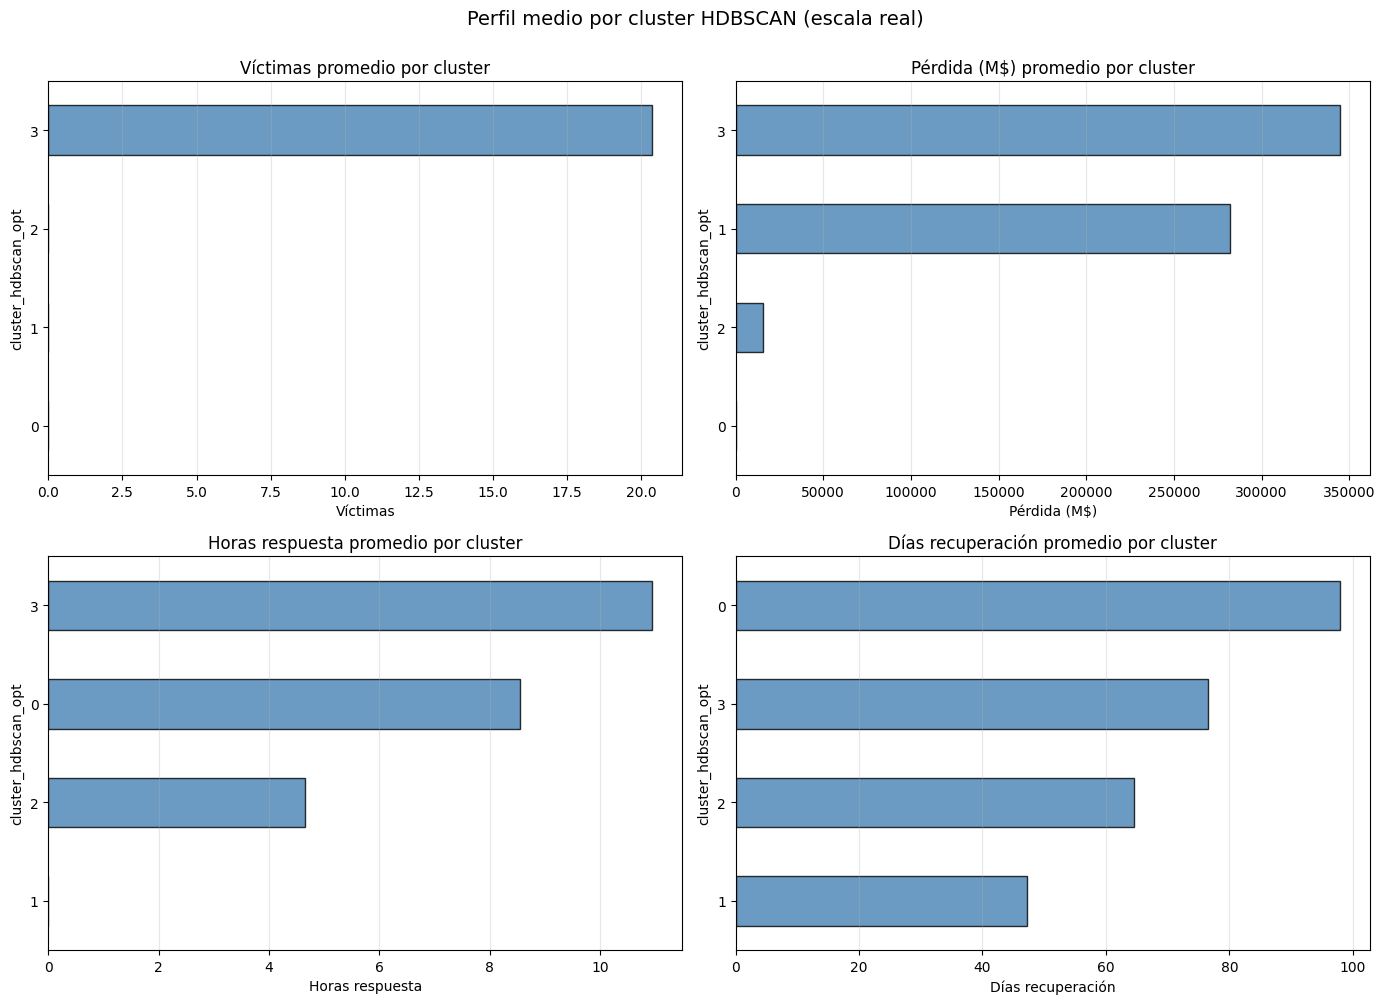


── Perfil medio por cluster (escala real) ──
                     Víctimas  Pérdida (M$)  Horas respuesta  \
cluster_hdbscan_opt                                            
0                         0.0           0.0              8.5   
1                         0.0      282266.9              0.0   
2                         0.0       15860.8              4.6   
3                        20.4      344469.7             10.9   

                     Días recuperación  
cluster_hdbscan_opt                     
0                                 97.9  
1                                 47.2  
2                                 64.5  
3                                 76.5  


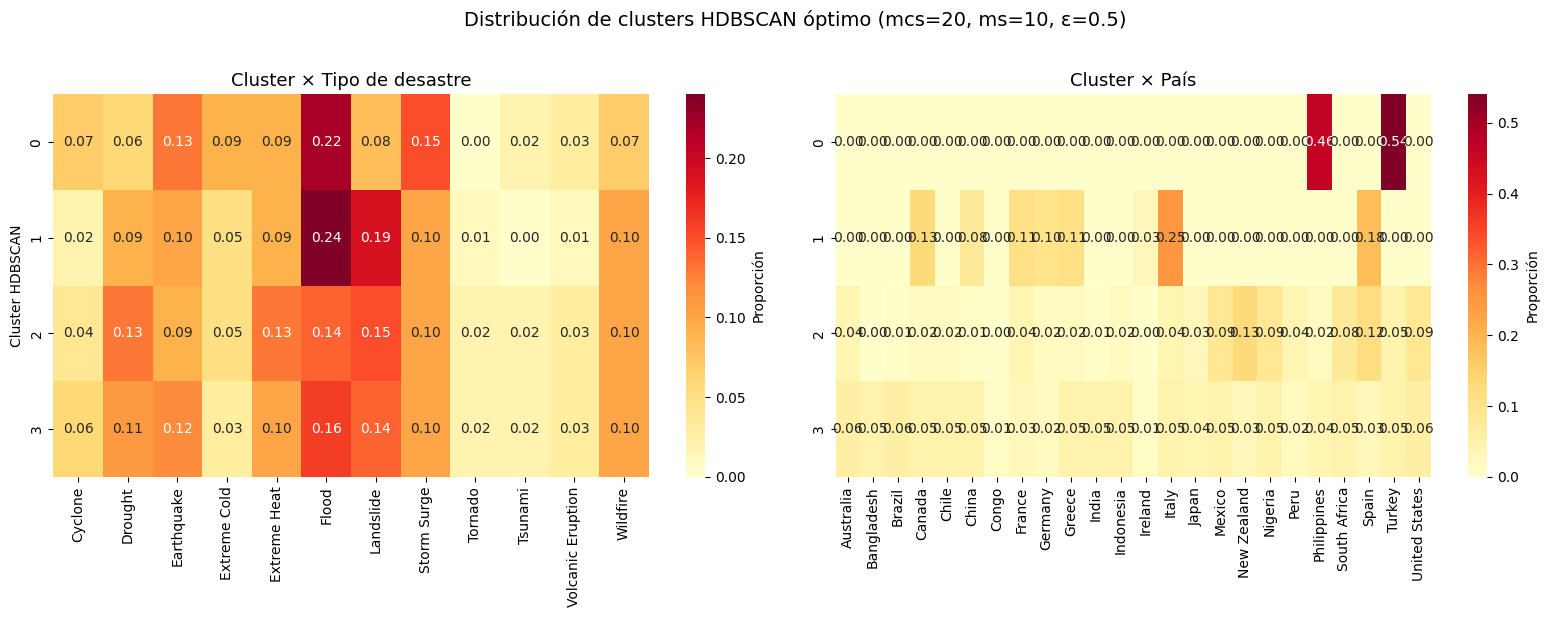


── Distribución por tipo de desastre (% por fila) ──
disaster_type        Cyclone  Drought  Earthquake  Extreme Cold  Extreme Heat  \
cluster_hdbscan_opt                                                             
0                       0.07     0.06        0.13          0.09          0.09   
1                       0.02     0.09        0.10          0.05          0.09   
2                       0.04     0.13        0.09          0.05          0.13   
3                       0.06     0.11        0.12          0.03          0.10   

disaster_type        Flood  Landslide  Storm Surge  Tornado  Tsunami  \
cluster_hdbscan_opt                                                    
0                     0.22       0.08         0.15     0.00     0.02   
1                     0.24       0.19         0.10     0.01     0.00   
2                     0.14       0.15         0.10     0.02     0.02   
3                     0.16       0.14         0.10     0.02     0.02   

disaster_type        Volca

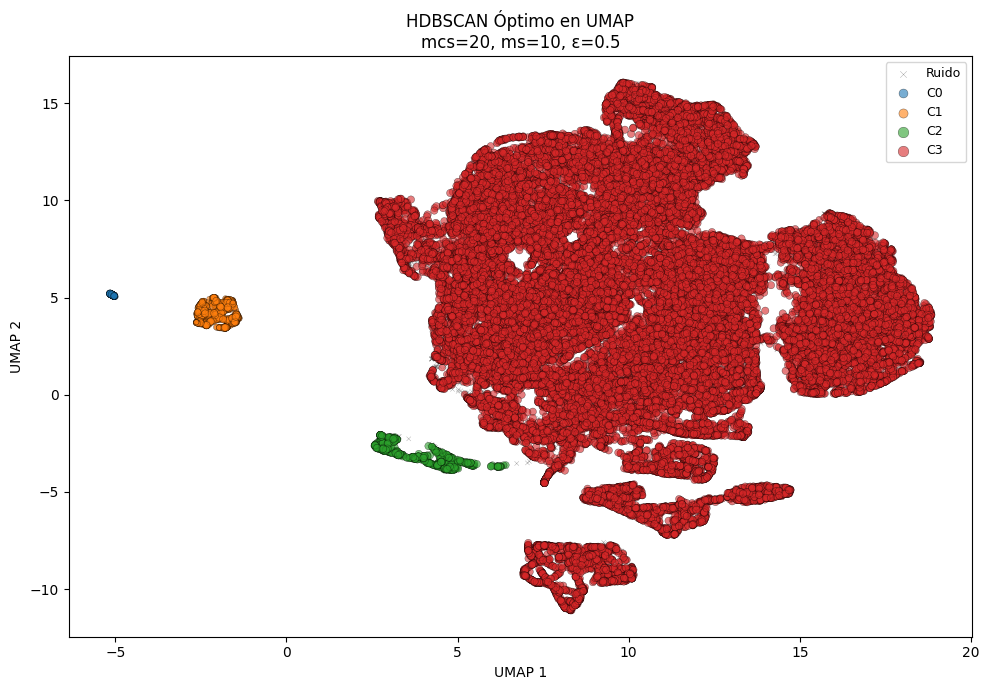


📊 COMPARACIÓN FINAL DE MÉTODOS
        Método  Clusters  % Ruido  Silhouette
  KMeans (k=3)         3      0.0      0.2155
        DBSCAN         4      0.1      0.2843
HDBSCAN Óptimo         4      2.3      0.2914


In [33]:
# ── 4. SELECCIONAR EL MEJOR MODELO ────────────────────────────────────────
mejor = candidatos.iloc[0]
print(f"\n🏆 Mejor combinación: mcs={mejor['mcs']}, ms={mejor['ms']}, ε={mejor['epsilon']}")
print(f"   Clusters: {mejor['n_clusters']}, Ruido: {mejor['pct_ruido']}%, Silhouette: {mejor['silhouette']}")

# ✅ CORRECCIÓN: Convertir explícitamente a float de Python
cl_mejor = hdbscan.HDBSCAN(
    min_cluster_size=int(mejor['mcs']),
    min_samples=int(mejor['ms']),
    cluster_selection_method='leaf',
    cluster_selection_epsilon=float(mejor['epsilon'])  # ✅ Convertir a float
).fit(X3_sc)

df['cluster_hdbscan_opt'] = cl_mejor.labels_
probs_opt = cl_mejor.probabilities_
df['hdbscan_prob_opt'] = probs_opt

print(f"\n✅ HDBSCAN entrenado correctamente con ε={float(mejor['epsilon'])}")
print(f"   Clusters encontrados: {len(set(cl_mejor.labels_)) - (1 if -1 in cl_mejor.labels_ else 0)}")
print(f"   Puntos de ruido: {(cl_mejor.labels_ == -1).sum()} ({(cl_mejor.labels_ == -1).sum()/len(cl_mejor.labels_)*100:.1f}%)")


# ── 5. VISUALIZACIÓN PCA ─────────────────────────────────────────────────
from sklearn.decomposition import PCA

pca_opt = PCA(n_components=2, random_state=42)
X_pca_opt = pca_opt.fit_transform(X3_sc)

fig = plt.figure(figsize=(16, 6))
gs = GridSpec(1, 3, figure=fig)

# ── Izquierda: Clusters ──
ax1 = fig.add_subplot(gs[0])
labels_opt = df['cluster_hdbscan_opt'].values
cluster_ids_opt = sorted(set(labels_opt))
n_clusters_opt = len([c for c in cluster_ids_opt if c != -1])

cmap_opt = plt.colormaps['tab10']
colores_opt = {cid: cmap_opt(i) for i, cid in enumerate(c for c in cluster_ids_opt if c != -1)}
colores_opt[-1] = (0.4, 0.4, 0.4, 0.4)

for cid in cluster_ids_opt:
    mask = labels_opt == cid
    nombre = f'C{cid}' if cid != -1 else 'Ruido'
    marker = 'o' if cid != -1 else 'x'
    sizes = (probs_opt[mask] * 25 + 3) if cid != -1 else np.full(mask.sum(), 8)
    ax1.scatter(X_pca_opt[mask, 0], X_pca_opt[mask, 1],
                color=colores_opt[cid], label=nombre,
                alpha=0.6, s=sizes, marker=marker, edgecolors='black', linewidth=0.3)

ax1.set_xlabel(f'PC1 ({pca_opt.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_opt.explained_variance_ratio_[1]:.1%})')
ax1.set_title(f'HDBSCAN Óptimo\nmcs={int(mejor["mcs"])}, ms={int(mejor["ms"])}, ε={float(mejor["epsilon"]):.1f}\n(tamaño ∝ probabilidad)')
ax1.legend(markerscale=1.5, fontsize=8, loc='best')

# ── Centro: Probabilidad de pertenencia ──
ax2 = fig.add_subplot(gs[1])
sc2 = ax2.scatter(X_pca_opt[:, 0], X_pca_opt[:, 1],
                  c=probs_opt, cmap='RdYlGn', alpha=0.6, s=8, vmin=0, vmax=1, edgecolors='none')
ax2.set_xlabel(f'PC1 ({pca_opt.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca_opt.explained_variance_ratio_[1]:.1%})')
ax2.set_title('Probabilidad de pertenencia\n(verde=núcleo, rojo=frontera)')
plt.colorbar(sc2, ax=ax2, label='Probabilidad')

# ── Derecha: Distribución de probabilidades ──
ax3 = fig.add_subplot(gs[2])
mask_no_ruido = labels_opt != -1
ax3.hist(probs_opt[mask_no_ruido], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axvline(probs_opt[mask_no_ruido].mean(), color='red', linestyle='--', 
            label=f'Media: {probs_opt[mask_no_ruido].mean():.3f}')
ax3.set_xlabel('Probabilidad de pertenencia')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de probabilidades\n(solo puntos asignados a clusters)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f'HDBSCAN Óptimo en PCA — {n_clusters_opt} clusters, {((labels_opt==-1).sum()/len(labels_opt)*100):.1f}% ruido', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ── 6. PERFIL MEDIO POR CLUSTER ──────────────────────────────────────────
df_sin_ruido_opt = df[df['cluster_hdbscan_opt'] != -1].copy()
perfil_opt = df_sin_ruido_opt.groupby('cluster_hdbscan_opt')[cols_clust].mean()
perfil_real_opt = np.expm1(perfil_opt)
perfil_real_opt.columns = ['Víctimas', 'Pérdida (M$)', 'Horas respuesta', 'Días recuperación']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(perfil_real_opt.columns):
    ax = axes[i]
    perfil_real_opt[col].sort_values().plot(kind='barh', ax=ax, color='steelblue', alpha=0.8, edgecolor='black')
    ax.set_xlabel(col)
    ax.set_title(f'{col} promedio por cluster')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Perfil medio por cluster HDBSCAN (escala real)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("\n── Perfil medio por cluster (escala real) ──")
print(perfil_real_opt.round(1))


# ── 7. HEATMAP: Cluster × Tipo de desastre (CON MANEJO DE ERRORES) ──────
disaster_cols = [c for c in df_sin_ruido_opt.columns if c.startswith('disaster_type_')]
country_cols = [c for c in df_sin_ruido_opt.columns if c.startswith('country_')]

if disaster_cols and country_cols:
    df_sin_ruido_opt = df_sin_ruido_opt.copy()
    df_sin_ruido_opt['disaster_type'] = (
        df_sin_ruido_opt[disaster_cols]
        .idxmax(axis=1)
        .str.replace('disaster_type_', '', regex=False)
    )
    df_sin_ruido_opt['country'] = (
        df_sin_ruido_opt[country_cols]
        .idxmax(axis=1)
        .str.replace('country_', '', regex=False)
    )

    ct_tipo_opt = pd.crosstab(df_sin_ruido_opt['cluster_hdbscan_opt'],
                              df_sin_ruido_opt['disaster_type'],
                              normalize='index').round(2)

    ct_pais_opt = pd.crosstab(df_sin_ruido_opt['cluster_hdbscan_opt'],
                              df_sin_ruido_opt['country'],
                              normalize='index').round(2)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    cmap_heat = plt.colormaps['YlOrRd']
    
    sns.heatmap(ct_tipo_opt, annot=True, fmt='.2f', cmap=cmap_heat, ax=axes[0], cbar_kws={'label': 'Proporción'})
    axes[0].set_title('Cluster × Tipo de desastre', fontsize=13)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Cluster HDBSCAN')

    sns.heatmap(ct_pais_opt, annot=True, fmt='.2f', cmap=cmap_heat, ax=axes[1], cbar_kws={'label': 'Proporción'})
    axes[1].set_title('Cluster × País', fontsize=13)
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')

    plt.suptitle(f'Distribución de clusters HDBSCAN óptimo (mcs={int(mejor["mcs"])}, ms={int(mejor["ms"])}, ε={float(mejor["epsilon"]):.1f})', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n── Distribución por tipo de desastre (% por fila) ──")
    print(ct_tipo_opt)
else:
    print("\n⚠️ No se encontraron columnas de tipo de desastre o país. Saltando heatmaps.")


# ── 8. VISUALIZACIÓN UMAP (si existe) ─────────────────────────────────────
if 'umap_1' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    for cid in cluster_ids_opt:
        mask = df['cluster_hdbscan_opt'] == cid
        nombre = f'C{cid}' if cid != -1 else 'Ruido'
        marker = 'o' if cid != -1 else 'x'
        sizes = (probs_opt[mask] * 25 + 3) if cid != -1 else np.full(mask.sum(), 10)
        ax.scatter(df.loc[mask, 'umap_1'], df.loc[mask, 'umap_2'],
                   color=colores_opt[cid], label=nombre,
                   alpha=0.6, s=sizes, marker=marker, edgecolors='black', linewidth=0.3)
    
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'HDBSCAN Óptimo en UMAP\nmcs={int(mejor["mcs"])}, ms={int(mejor["ms"])}, ε={float(mejor["epsilon"]):.1f}')
    ax.legend(markerscale=1.5, fontsize=9, loc='best')
    plt.tight_layout()
    plt.show()


# ── 9. TABLA RESUMEN COMPARATIVA ─────────────────────────────────────────
kmeans_col = next((c for c in ['cluster', 'cluster_eda', 'cluster_k3'] if c in df.columns), None)
dbscan_col = next((c for c in ['cluster_dbscan', 'cluster_db'] if c in df.columns), None)

resumen = pd.DataFrame({
    'Método': ['KMeans (k=3)', 'DBSCAN', f'HDBSCAN Óptimo'],
    'Clusters': [
        3,
        len(set(df[dbscan_col])) - (1 if -1 in df[dbscan_col].values else 0) if dbscan_col else np.nan,
        n_clusters_opt
    ],
    '% Ruido': [
        0.0,
        round((df[dbscan_col] == -1).sum() / len(df) * 100, 1) if dbscan_col else np.nan,
        round((labels_opt == -1).sum() / len(labels_opt) * 100, 1)
    ],
    'Silhouette': [
        round(silhouette_score(X3_sc, df[kmeans_col]), 4) if kmeans_col else np.nan,
        round(silhouette_score(X3_sc[df[dbscan_col]!=-1], df[dbscan_col][df[dbscan_col]!=-1]), 4) if dbscan_col else np.nan,
        round(silhouette_score(X3_sc[mask_no_ruido], labels_opt[mask_no_ruido]), 4)
    ]
})

print("\n" + "="*60)
print("📊 COMPARACIÓN FINAL DE MÉTODOS")
print("="*60)
print(resumen.to_string(index=False))
print("="*60)